# OPC analysis: PSD-based single and two-component kinetic inference

This notebook implements a complete OPC (optical patch-clamp) analysis pipeline based on **frequency-domain kinetics**.  
The workflow begins with **camera-calibrated, Poisson-consistent denoising** of the fluorescence stack and proceeds to **per-pixel PSD fitting**, using a **Fluo-5 dye-blinking prior** for model anchoring and a **two-component Lorentzian test** to detect additional kinetic modes.

The ultimate goal is to extract spatial maps of **dye-only dynamics** versus **dye + extra correlation processes**, without relying on discrete-state idealization.

---

## Preprocessing pipeline: calibration and Poisson-consistent multiscale denoising

The first stage converts raw ADU frames into physically meaningful **photon counts per frame**, and denoises them with a multiscale, variance-aware algorithm that preserves kinetic signatures such as dye blinking and Ca²⁺-dependent emission fluctuations.

### 1) Calibration: ADU → photons per frame

The raw stack $I_{\mathrm{ADU}}(t,y,x)$ is mapped to photon counts using detector calibration parameters — photon gain $g$, offset $o$, and background rate $b$:

$$
N(t,y,x) = \frac{I_{\mathrm{ADU}}(t,y,x) - o}{g} - b.
$$

Negative or nonfinite values are clipped to $0$ to preserve Poisson consistency.

**Parameter definitions**

| Symbol | Meaning | Source |
|:--|:--|:--|
| $g$ | Photon gain [ADU/photon] | Photon-transfer calibration |
| $o$ | Offset [ADU] | Dark-frame mean |
| $b$ | Background photons/frame | Zero-illumination extrapolation |

---

### 2) Poisson-consistent denoising using the Binlets transform

Photon detection noise follows $\mathrm{Var}(N)\approx N$.  
The **Binlets algorithm** performs a non-decimated, multiscale averaging (MODWT-like) that merges coefficients only when differences are statistically compatible with Poisson noise.

#### Multiscale Poisson test

Two coefficients $(a,b)$ are merged if
$$
(a-b)^2 \le (n_\sigma)^2 (a+b),
$$
consistent with Poisson fluctuations.  
Otherwise, structural differences are preserved.

#### Joint 3-D implementation

For a 3-D photon field $N(t,y,x)$, the transform operates jointly along $(t,y,x)$, applying merge operations according to the criterion above:

$$
N_{\mathrm{den}}(t,y,x)
=
\mathcal{B}^{-1}_L\!\big( \mathrm{merge}_{n_\sigma}(\mathcal{B}_L[N]) \big),
$$
where $\mathcal{B}_L$ is the non-decimated Binlets transform at level $L$.

The output  
$$
S(t,y,x) = N_{\mathrm{den}}(t,y,x)
$$
is a **Poisson-consistent, multiscale-denoised photon field** suitable for kinetic inference.

---

## PSD analysis of denoised counts

Each pixel’s denoised time series $S(t)$ is treated as the fundamental observable describing local fluorescence fluctuations.  
Its **one-sided power spectral density (PSD)**,

$$
G(f),
$$

captures the temporal correlation structure required for kinetic inference.

Many stochastic photophysical and biochemical processes yield Lorentzian spectral components of the form
$$
G(f) = \frac{C_0}{1 + (f/f_c)^2},
\qquad
\tau_c = \frac{1}{2\pi f_c}.
$$

---

## Single-component Lorentzian model with Fluo-5 dye-blinking prior

Isolated Fluo-5 molecules blink with a reproducible correlation time $\tau_{\text{dye}}$ measured independently on coverslip samples.  
This dye-blinking component provides a **strong prior** for identifying pixels whose spectra arise solely from intrinsic dye dynamics.

We first fit each pixel with a **single Lorentzian** in which:

- The corner frequency $f_{c,\text{dye}}$ is fixed or tightly constrained around the calibrated value.
- The amplitude $C_{0,\text{dye}}$ is free per pixel.

Pixels well described by this constrained model are classified as **dye-only**.

---

## Two-component model: dye blinking + additional correlation process

Pixels exhibiting correlated power beyond dye blinking are tested with a **two-component Lorentzian model**:

$$
G_{2c}(f) =
\frac{C_{0,\text{dye}}}{1 + (f/f_{c,\text{dye}})^2}
+
\frac{C_{0,\text{extra}}}{1 + (f/f_{c,\text{extra}})^2}.
$$

Only the parameters $(C_{0,\text{extra}}, f_{c,\text{extra}})$ of the second component are free.  
Improvement over the dye-only model suggests the presence of **additional correlated dynamics**, such as Ca²⁺ microdomain fluctuations or local biochemical modes.

---

## Model selection: one vs two components

To determine which model is supported at each pixel, we compare:

- log–log $R^2$,  
- AICc,  
- and a residual curvature metric (S-shape test).

Classification:

- **Dye-only**: constrained single-component model sufficient.  
- **Dye + extra**: two-component model significantly improves fit.  
- **Ambiguous / low SNR**: neither model reliable.

This yields high-resolution maps of **where** additional kinetics occur and **what time scales** they occupy.

---

## Interpretation of extra kinetic components

For pixels requiring a second Lorentzian, the additional component has parameters $(C_{0,\text{extra}}, f_{c,\text{extra}})$ and correlation time

$$
\tau_{\text{extra}} = \frac{1}{2\pi f_{c,\text{extra}}}.
$$

This timescale reflects **non-dye processes** such as Ca²⁺ buffering, microdomain fluctuations, or collective channel behavior.  
Because the analysis is entirely frequency-domain and fully grounded in Poisson-consistent denoised photon counts, all inferred timescales remain physically interpretable and internally consistent.

# Libraries

In [7]:
import os
import tifffile
import numpy as np
import matplotlib.pyplot as plt

from binlets import binlets
import napari

from scipy import signal
from scipy.optimize import curve_fit

from joblib import Parallel, delayed
from dataclasses import dataclass
from typing import Optional, Tuple, Dict

# Parameters

In [8]:
# ============================================
# Input data path
# ============================================
#img_path = "/Users/adanguerrero/Desktop/tmp/M6_sinNED/roi_00_mib1.ome.tif"
#img_path = "/Users/adanguerrero/Desktop/tmp/M6_sinNED/roi_00_ctr.ome.tif"
#img_path = "/Users/adanguerrero/Desktop/tmp/M6_sinNED/roi_00_iono.ome.tif"
img_path = "Sphere_in_Fluo5N_no_AM_5nM_Calcium_5mM_48000frames.tif"
# ============================================
# Acquisition and preprocessing parameters
# ============================================
par = dict(
    # --- Acquisition parameters ---
    fs=8000.0,            # Sampling frequency in Hz (frames per second)

    # --- Camera calibration (from photon-transfer) ---
    photon_gain=1.528,    # ADU/photon     ← measured
    offset=127.539,       # ADU            ← measured
    background_rate=0.0,  # photons/frame (below detection threshold) ← measured

    # --- Approximate single-dye brightness scale ---
    # Fluorescence amplitude per bright dye (photons/frame). Used only
    # for approximate scaling and visualization, not for Nc estimation.
    amplitude_per_pair=1.12,

    # --- Binlets denoising (Poisson-consistent multiscale filter) ---
    L=3,                  # Number of multiscale levels (3–7 reasonable at 8000 Hz)
    n_sigma=3.0           # Poisson consistency threshold
)

# Conversion factor from samples to milliseconds
to_ms = 1000.0 / par["fs"]

# ============================================
# Time window for analysis (subsampling in t)
# ============================================
n_stp = 1                # Number of segments to analyze (increase for more data)
stp_size = 4096          # Length of each segment in frames
t_range = np.arange(n_stp * stp_size)   # 0, 1, ..., n_stp*stp_size - 1

# ============================================
# PSD analysis parameters (Welch + log-binning)
# ============================================
PSD_ANALYSIS_PARAMS = dict(
    fs=par["fs"],
    nperseg=None,         # If None: automatic choice based on trace length
    noverlap=None,        # If None: default to nperseg // 2 in analysis code
    subtract_floor=False,
    floor_top_frac=0.2,
    use_logbin=True,
    nbins=60,
    band=(0, 1000),       # Frequency band of interest [Hz]
    make_plot=True,
    psd_avg_segments=2    # Number of temporal segments to average per pixel
)

# ============================================
# Prior for Fluo-5 dye blinking (from calibration)
# ============================================
DYE_PRIOR = dict(
    # Characteristic dye-blinking correlation time (ms).
    # Replace this value with the one measured on coverslip calibration.
    tau_dye_ms=0.60,

    # Relative tolerance around tau_dye_ms for constrained 1c fits,
    # for example ±30 percent.
    tau_dye_rel_tol=0.30
)

# ============================================
# Quality control and model-selection parameters
# ============================================
SLOPE_TOL_LOW        = 1.5
SLOPE_TOL_HIGH       = 1.0
MIN_INBAND_SHAPE     = 20
SSHAPE_MAG_MIN       = 0.25    # Decrease to detect more 2c candidates
SSHAPE_P_MAX         = 0.005   # Increase to be more permissive
AICC_STRONG_IMPROVEMENT = -6.0
MIN_MARGIN_FOR_MC    = 0.02
SHORT_T_MAX          = 3.5
MIN_INBAND_SLOPE     = 25
MIN_FREQ_SPAN_FOR_SLOPE = 3.0

# =============================
# Color palette (Okabe–Ito)
# =============================
COL_RAW = "#999999"   # Raw (ADU or counts)
COL_DEN = "#0072B2"   # Denoised counts

# =========================
# Theme for PSD plots
# =========================
COL_DATA = "#777777"  # PSD data
COL_FIT  = "#000000"  # 1c model
COL_FIT2 = "#0072B2"  # 2c model (extra component)
COL_FC   = "#2f855a"  # fc markers
COL_BAR  = "#5e5e5e"  # bars (for summary plots)

# Functions

In [9]:
# ============================================================
# Calibration-aware converters (ADU <-> photons/frame)
# ============================================================

def adu_to_counts(
    adu: np.ndarray,
    gain: float,
    offset: float,
    background_rate: float = 0.0,
    *,
    clip_nonneg: bool = True,
    out_dtype=np.float32
) -> np.ndarray:
    """
    Convert camera ADU to photon counts per frame (expected value).

    Parameters
    ----------
    adu : ndarray
        Raw signal in ADU.
    gain : float
        Photon gain in ADU/photon (from photon-transfer curve).
    offset : float
        Electronic offset (ADU) measured from dark frames.
    background_rate : float, optional
        Background photons/frame to subtract (dark current + stray light).
        Use the value extrapolated at zero illumination. Set 0.0 if negligible.
    clip_nonneg : bool
        If True, negative values after subtraction are floored to zero.
    out_dtype : numpy dtype
        Output dtype.

    Returns
    -------
    counts : ndarray
        Expected photon counts per frame, in photons/frame.
    """
    adu = np.asarray(adu, dtype=np.float32, order="C")
    g = max(float(gain), 1e-12)
    counts = (adu - float(offset)) / g
    counts = counts - float(background_rate)
    counts = np.nan_to_num(counts, nan=0.0, posinf=0.0, neginf=0.0)
    if clip_nonneg:
        counts = np.clip(counts, 0.0, None)
    return counts.astype(out_dtype, copy=False)


def counts_to_adu(
    counts: np.ndarray,
    gain: float,
    offset: float,
    *,
    out_dtype=np.float32
) -> np.ndarray:
    """
    Convert photon counts per frame back to ADU (deterministic mapping, no noise).

    Parameters
    ----------
    counts : ndarray
        Photon counts per frame.
    gain : float
        Photon gain in ADU/photon.
    offset : float
        Electronic offset in ADU.
    out_dtype : numpy dtype
        Output dtype.

    Returns
    -------
    adu : ndarray
        Intensity in ADU.
    """
    return (np.asarray(counts, np.float32) * float(gain) + float(offset)).astype(
        out_dtype,
        copy=False,
    )


# ============================================================
# Poisson-consistent Binlets denoising
# ============================================================

# ---------- Poisson merge test ----------
def _poisson_test(a: np.ndarray, b: np.ndarray, n_sigma: float) -> np.ndarray:
    """
    Poisson-consistent merge test.

    Merge if (a - b)^2 <= (n_sigma^2) * (a + b), using Var(N) ≈ N.
    """
    a = np.clip(a, 0.0, None)
    b = np.clip(b, 0.0, None)
    var = np.maximum(a + b, 1e-12)
    return (a - b) ** 2 <= (n_sigma ** 2) * var


# ---------- Joint 3-D Poisson binlets (counts domain) ----------
def poisson_binlets_joint_3d_counts(
    counts_txy: np.ndarray,
    levels: int,
    n_sigma: float,
    linear: bool = True,
) -> np.ndarray:
    """
    Run Binlets on a (t, y, x) counts array using a Poisson noise model.

    Parameters
    ----------
    counts_txy : ndarray (T, Y, X)
        Photon counts per frame.
    levels : int
        Number of multiscale levels in the Binlets transform.
    n_sigma : float
        Poisson significance threshold in the merge test.
    linear : bool
        Use linear reconstruction in the Binlets transform.

    Returns
    -------
    counts_den : ndarray (T, Y, X)
        Denoised photon counts per frame.
    """
    counts_txy = np.asarray(counts_txy, dtype=np.float32, order="C")
    if counts_txy.ndim != 3:
        raise ValueError(f"Expected input shape (t, y, x). Got: {counts_txy.shape}")

    X = counts_txy[None, ...]  # binlets expects (channels, t, y, x)

    def test(a, b):
        return _poisson_test(a, b, n_sigma)

    X_den = binlets(X, test=test, levels=int(levels), linear=linear)
    return X_den[0]  # return (t, y, x)


def denoise_fluo_stack(
    adu: np.ndarray,
    par: dict,
    *,
    out_dtype=np.float32,
    linear: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    """
    Preprocess a fluorescence stack by converting from ADU to photon counts,
    applying Poisson-consistent Binlets denoising, and reconverting to ADU.

    Parameters
    ----------
    adu : ndarray (T, Y, X)
        Raw image stack in Analog–Digital Units (ADU).
    par : dict
        Dictionary with calibration and denoising parameters:
            photon_gain      : float  [ADU/photon]
            offset           : float  [ADU]
            background_rate  : float  [photons/frame] (optional)
            L                : int    number of Binlets levels
            n_sigma          : float  Poisson significance threshold
    out_dtype : dtype, optional
        Output data type for denoised arrays (default np.float32).
    linear : bool, optional
        Use linear reconstruction in the Binlets transform (default True).

    Returns
    -------
    counts_den : ndarray (T, Y, X)
        Denoised stack in photon counts per frame.
    adu_den : ndarray (T, Y, X)
        Denoised stack in ADU (camera units).
    """

    # --- 1. Convert ADU → photon counts --------------------------------------
    counts = adu_to_counts(
        adu,
        gain=float(par["photon_gain"]),
        offset=float(par["offset"]),
        background_rate=float(par.get("background_rate", 0.0)),
        out_dtype=out_dtype,
        clip_nonneg=True,
    )

    # --- 2. Poisson-consistent denoising -------------------------------------
    counts_den = poisson_binlets_joint_3d_counts(
        counts,
        levels=int(par["L"]),
        n_sigma=float(par["n_sigma"]),
        linear=linear,
    )

    # --- 3. Reconversion to ADU (optional visualization) ---------------------
    adu_den = counts_to_adu(
        counts_den,
        gain=float(par["photon_gain"]),
        offset=float(par["offset"]),
        out_dtype=out_dtype,
    )

    return counts_den, adu_den


def denoise_fluo_stack_chunked(
    img_path: str,
    par: dict,
    *,
    chunk_size: int = 12000,
    verbose: bool = True
) -> tuple[np.ndarray, np.ndarray]:
    """
    Denoise large fluorescence stacks by processing consecutive non-overlapping
    temporal chunks and concatenating the outputs.

    Parameters
    ----------
    img_path : str
        Path to the raw OME-TIFF file.
    par : dict
        Calibration and denoising parameters (see denoise_fluo_stack).
    chunk_size : int
        Number of frames per chunk along the time axis.
    verbose : bool
        If True, print progress information.

    Returns
    -------
    counts_den_full : ndarray (T, Y, X)
        Denoised stack in photon counts per frame.
    adu_den_full : ndarray (T, Y, X)
        Denoised stack in ADU.
    """
    # Load raw data (t, y, x)
    adu = tifffile.imread(img_path).astype(np.float32, copy=False)
    t_total = adu.shape[0]

    # Compute chunk indices (non-overlapping)
    starts = np.arange(0, t_total, chunk_size)
    ends = np.minimum(starts + chunk_size, t_total)

    if verbose:
        print(f"Total frames: {t_total}")
        print(f"Processing in {len(starts)} chunk(s) of ≤ {chunk_size} frames")

    counts_all, adu_all = [], []
    for i, (s0, s1) in enumerate(zip(starts, ends)):
        if verbose:
            print(f"  Chunk {i + 1}/{len(starts)} → frames {s0}:{s1}")
        adu_chunk = adu[s0:s1]
        counts_den, adu_den = denoise_fluo_stack(adu_chunk, par)
        counts_all.append(counts_den)
        adu_all.append(adu_den)

    # Concatenate along time axis
    counts_den_full = np.concatenate(counts_all, axis=0)
    adu_den_full = np.concatenate(adu_all, axis=0)

    if verbose:
        print(f"Reconstructed full denoised stack: {counts_den_full.shape}")

    return counts_den_full, adu_den_full


# ============================================================
# PSD analysis utilities
# ============================================================

def _as_pos_int(x, minval: int = 1) -> int:
    """
    Convert x to a positive integer with a minimal value minval.
    """
    return int(max(minval, int(round(float(x)))))


# ---------- Robust R² utilities ----------
def r2_score_safe(
    y: np.ndarray,
    yhat: np.ndarray,
    *,
    atol: float = 1e-12
) -> Tuple[float, np.ndarray]:
    """
    Robust coefficient of determination R².
    Returns NaN when the target variance is (numerically) zero but residuals are nonzero.

    Parameters
    ----------
    y : ndarray
        Observed values.
    yhat : ndarray
        Predicted values.
    atol : float
        Absolute tolerance for considering variance equal to zero.

    Returns
    -------
    r2 : float
        Robust R² estimate.
    mask : ndarray (bool)
        Mask of finite points used in the calculation.
    """
    y = np.asarray(y, dtype=float)
    yhat = np.asarray(yhat, dtype=float)
    m = np.isfinite(y) & np.isfinite(yhat)

    if m.sum() < 2:
        return np.nan, m

    y = y[m]
    yhat = yhat[m]

    y_mean = y.mean()
    ss_res = float(np.sum((y - yhat) ** 2))
    ss_tot = float(np.sum((y - y_mean) ** 2))

    if ss_tot <= atol:
        if ss_res <= atol:
            return 1.0, m  # perfectly constant and perfectly matched
        return np.nan, m  # undefined R² on constant target

    with np.errstate(divide="ignore", invalid="ignore"):
        r2 = 1.0 - (ss_res / ss_tot)
    return float(r2), m


# ---------- Welch PSD (single vector) ----------
def welch_psd_level(
    x,
    fs: float,
    nperseg: Optional[int] = None,
    noverlap: Optional[int] = None
):
    """
    Compute the one-sided PSD using Welch’s method for a single time series.
    """
    x = np.asarray(x, float)
    n = x.size
    if nperseg is None:
        # Robust default: power of two, ~1/6 of record or 1024 minimum
        nperseg = int(2 ** np.floor(np.log2(max(1024, n // 6))))
    if noverlap is None:
        noverlap = int(0.75 * nperseg)
    nperseg = min(nperseg, n)
    f, G = signal.welch(
        x,
        fs=fs,
        nperseg=nperseg,
        noverlap=noverlap,
        detrend="constant",
        return_onesided=True,
        scaling="density",
    )
    return f, G, nperseg, noverlap


# ---------- PSD average over K segments ----------
def welch_psd_average_segments(
    x,
    fs: float,
    k_segments: int = 1,
    nperseg: Optional[int] = None,
    noverlap: Optional[int] = None
):
    """
    Compute Welch PSD and optionally average across k_segments contiguous segments
    to stabilize the low-frequency regime.

    Parameters
    ----------
    x : array_like
        Time series.
    fs : float
        Sampling frequency in Hz.
    k_segments : int
        Number of segments to average.
    nperseg, noverlap : int or None
        Welch parameters; if None, sensible defaults are used.

    Returns
    -------
    f : ndarray
        Frequency axis (Hz).
    G : ndarray
        Averaged one-sided PSD.
    nperseg : int
        Effective segment length used.
    noverlap : int
        Effective overlap used.
    """
    x = np.asarray(x, float)
    k_segments = _as_pos_int(k_segments, 1)
    if k_segments == 1:
        return welch_psd_level(x, fs, nperseg=nperseg, noverlap=noverlap)

    parts = np.array_split(x, k_segments)
    f_ref, G_accum = None, None
    nps_use, nov_use = None, None
    for p in parts:
        f, G, nps, nov = welch_psd_level(p, fs, nperseg=nperseg, noverlap=noverlap)
        if f_ref is None:
            f_ref = f
            G_accum = np.zeros_like(G, dtype=float)
            nps_use, nov_use = nps, nov
        else:
            # Ensure identical frequency axis by log-log interpolation if needed
            if len(f) != len(f_ref) or not np.allclose(f, f_ref):
                G = 10 ** np.interp(
                    np.log10(f_ref),
                    np.log10(f + 1e-30),
                    np.log10(G + 1e-300),
                )
        G_accum += G
    G_mean = G_accum / k_segments
    return f_ref, G_mean, nps_use, nov_use


# ---------- Discrete-time frequency warping (bilinear) ----------
def feq_bilinear(f, fs: float):
    """
    Bilinear frequency mapping to account for discrete-time sampling.
    """
    f = np.asarray(f, float)
    return (fs / np.pi) * np.tan(np.pi * f / fs)


# ---------- Robust high-frequency floor estimate ----------
def estimate_flat_floor(G, top_frac: float = 0.2) -> float:
    """
    Estimate a flat noise floor from the top fraction of the PSD tail.
    """
    G = np.asarray(G, float)
    m = max(1, int(np.floor(top_frac * G.size)))
    tail = np.partition(G, -m)[-m:]
    tail = tail[np.isfinite(tail)]
    return float(max(np.median(tail), 0.0)) if tail.size else 0.0


# ---------- Log-binning ----------
def log_bin(f, y, nbins: int = 60):
    """
    Logarithmic binning of (f, y) to homogenize sampling in log-frequency.
    """
    nbins = _as_pos_int(nbins, 4)
    f = np.asarray(f)
    y = np.asarray(y)
    m = np.isfinite(f) & np.isfinite(y) & (f > 0) & (y > 0)
    f, y = f[m], y[m]
    if f.size == 0:
        return np.array([]), np.array([])
    if np.allclose(f.min(), f.max()):
        return np.array([float(f.min())]), np.array([float(np.median(y))])
    edges = np.logspace(np.log10(f.min()), np.log10(f.max()), nbins + 1)
    out_f, out_y = [], []
    for i in range(nbins):
        s = (f >= edges[i]) & (f < edges[i + 1])
        if np.any(s):
            out_f.append(np.exp(np.mean(np.log(f[s]))))
            out_y.append(np.exp(np.mean(np.log(y[s]))))
    return np.array(out_f), np.array(out_y)


# ============================================================
# Single- and two-component Lorentzian PSD models
# ============================================================

def fit_single_lorentzian(
    f,
    G,
    fs: float,
    fmin: Optional[float] = None,
    fmax: Optional[float] = None,
    use_logbin: bool = True,
    nbins: int = 60
):
    """
    Fit a single Lorentzian to a PSD using a coarse grid over fc and
    closed-form least squares for C0.

    Returns
    -------
    C0 : float
        Lorentzian amplitude.
    fc : float
        Corner frequency in Hz.
    tau_c : float
        Correlation time in seconds.
    G_hat : ndarray
        Fitted Lorentzian evaluated at the original f grid.
    meta : tuple
        Additional metadata (e.g. number of in-band points).
    """
    f = np.asarray(f)
    G = np.asarray(G)
    m = np.isfinite(f) & np.isfinite(G) & (G > 0)
    if fmin is not None:
        m &= f >= fmin
    if fmax is not None:
        m &= f <= fmax
    f_fit, G_fit = f[m], G[m]
    if f_fit.size < 8:
        return np.nan, np.nan, np.nan, np.full_like(f, np.nan), (f_fit.size,)

    if use_logbin:
        f_fit, G_fit = log_bin(f_fit, G_fit, nbins=_as_pos_int(nbins, 16))
        if f_fit.size < 8:
            return np.nan, np.nan, np.nan, np.full_like(f, np.nan), (f_fit.size,)

    feq = feq_bilinear(f_fit, fs)
    w = np.ones_like(f_fit)
    w2 = w * w

    low_med = float(np.median(G_fit[: max(3, G_fit.size // 12)]))
    idx = np.argmax(G_fit <= 0.5 * low_med)
    fc_rough = feq[idx] if idx > 0 else np.median(feq)
    fc_lo = max(feq.min(), fc_rough / 6.0)
    fc_hi = min(feq.max(), fc_rough * 6.0)
    if fc_hi <= 1.5 * fc_lo:
        fc_hi = fc_lo * 3.0
    fc_grid = np.logspace(np.log10(fc_lo), np.log10(fc_hi), _as_pos_int(180))

    best = None
    for fc in fc_grid:
        denom = 1.0 + (feq / fc) ** 2
        C0 = np.sum(w2 * G_fit / denom) / np.sum(w2 / (denom * denom))
        pred = C0 / denom
        sse = np.sum(w2 * (G_fit - pred) ** 2)
        if (best is None) or (sse < best[0]):
            best = (sse, float(C0), float(fc))

    _, C0, fc = best
    tau_c = 1.0 / (2.0 * np.pi * fc)
    G_hat = C0 / (1.0 + (feq_bilinear(f, fs) / fc) ** 2)
    return C0, fc, tau_c, G_hat, (f_fit.size,)


def fit_two_lorentzians_coarse(
    f,
    G,
    fs: float,
    fmin: Optional[float] = None,
    fmax: Optional[float] = None,
    nbins: int = 48,
    grid_points: int = 18,
    min_ratio: float = 2.0
):
    """
    Coarse two-Lorentzian fit: grid over fc1, fc2 and closed-form
    least squares for C01, C02.

    Parameters are chosen to provide seeds for later nonlinear refinement.

    Returns
    -------
    C01, fc1, C02, fc2, G_hat, info
    where info contains at least n_inband.
    """
    nbins = _as_pos_int(nbins, 24)
    grid_points = _as_pos_int(grid_points, 10)

    f = np.asarray(f)
    G = np.asarray(G)
    m = np.isfinite(f) & np.isfinite(G) & (G > 0)
    if fmin is not None:
        m &= f >= fmin
    if fmax is not None:
        m &= f <= fmax
    f_fit, G_fit = f[m], G[m]
    if f_fit.size < 12:
        return *(np.nan,) * 5, {"n_inband": int(f_fit.size)}

    f_fit, G_fit = log_bin(f_fit, G_fit, nbins=nbins)
    if f_fit.size < 12:
        return *(np.nan,) * 5, {"n_inband": int(f_fit.size)}

    feq = feq_bilinear(f_fit, fs)
    feq_all = feq_bilinear(f, fs)
    lo, hi = feq.min(), feq.max()
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return *(np.nan,) * 5, {"n_inband": int(f_fit.size)}
    fc_grid = np.logspace(np.log10(lo), np.log10(hi), grid_points)

    W = np.ones_like(f_fit)
    best = None

    for i in range(len(fc_grid)):
        for j in range(i + 1, len(fc_grid)):
            fc1, fc2 = fc_grid[i], fc_grid[j]
            if (fc2 / fc1) < float(min_ratio):
                continue
            d1 = 1.0 / (1.0 + (feq / fc1) ** 2)
            d2 = 1.0 / (1.0 + (feq / fc2) ** 2)
            A = np.vstack([d1, d2]).T
            Aw = A * W[:, None]
            bw = G_fit * W
            try:
                Cvec, *_ = np.linalg.lstsq(Aw, bw, rcond=None)
            except np.linalg.LinAlgError:
                continue
            C01, C02 = float(Cvec[0]), float(Cvec[1])
            if (C01 <= 0) or (C02 <= 0):
                continue
            pred = C01 * d1 + C02 * d2
            sse = float(np.sum((W * (G_fit - pred)) ** 2))
            if (best is None) or (sse < best[0]):
                best = (sse, C01, fc1, C02, fc2)

    if best is None:
        return *(np.nan,) * 5, {"n_inband": int(f_fit.size)}

    _, C01, fc1, C02, fc2 = best
    d1_all = 1.0 / (1.0 + (feq_all / fc1) ** 2)
    d2_all = 1.0 / (1.0 + (feq_all / fc2) ** 2)
    G_hat = C01 * d1_all + C02 * d2_all
    return C01, fc1, C02, fc2, G_hat, {"n_inband": int(f_fit.size)}


# ---------- Automatic band selection ----------
def auto_band(f, Gc, fs: float, T: float) -> Tuple[float, float]:
    """
    Select a frequency band [fmin, fmax] for fitting, excluding DC and
    Nyquist-adjacent artefacts and centering around the Lorentzian knee.
    """
    base = float(np.median(Gc[: max(8, Gc.size // 20)]))
    idx = np.argmax(Gc <= 0.7 * base)
    feq = feq_bilinear(f, fs)
    fc_guess = feq[idx] if idx > 0 else np.median(feq)
    fmin = max(3.0 / T, 0.1 * fc_guess)
    fmax = min(0.24 * fs, f[-2])
    fmin = max(fmin, f[1])
    return float(fmin), float(fmax)


# ============================================================
# Mapping (C0, tau_c) to effective two-state kinetics
# ============================================================

def kinetics_from_C0_tau(S, C0: float, tau_c: float) -> Dict[str, float]:
    """
    Infer effective two-state kinetic quantities from (C0, tau_c) and the
    mean signal S. This mapping assumes a two-state Markov process and is
    mainly used as an interpretable summary. Values are set to NaN if the
    inferred parameters are non-physical.

    Parameters
    ----------
    S : array_like
        Time series used to estimate the mean photon count Np.
    C0 : float
        Lorentzian PSD amplitude.
    tau_c : float
        Correlation time in seconds.

    Returns
    -------
    dict
        Dictionary containing Np, C0, tau_c, fc, and effective
        (Nc, p, k_open, k_close, tau_open, tau_closed), with NaNs when
        the mapping is not physically consistent.
    """
    S = np.asarray(S, float)
    Np = float(np.mean(S))

    if tau_c <= 0 or C0 < 0 or (not np.isfinite(tau_c)) or (not np.isfinite(C0)):
        keys = [
            "Nc", "p", "Np", "Np1mp", "C0", "tau_c", "fc",
            "k_open", "k_close", "tau_open", "tau_closed",
        ]
        return {k: (Np if k == "Np" else np.nan) for k in keys}

    Np1mp = C0 / (4.0 * tau_c)
    if (not np.isfinite(Np1mp)) or (Np1mp < 0):
        keys = [
            "Nc", "p", "Np", "Np1mp", "C0", "tau_c", "fc",
            "k_open", "k_close", "tau_open", "tau_closed",
        ]
        return {k: (Np if k == "Np" else np.nan) for k in keys}

    denom = Np - Np1mp
    if denom <= 0 or (not np.isfinite(denom)):
        Nc = np.nan
        p = np.nan
    else:
        Nc = (Np ** 2) / denom
        if Nc <= 0 or (not np.isfinite(Nc)):
            Nc = np.nan
            p = np.nan
        else:
            p = Np / Nc
            if (p < 0) or (p > 1) or (not np.isfinite(p)):
                p = np.nan
                Nc = np.nan

    k_sum = 1.0 / tau_c
    if (not np.isfinite(k_sum)) or (k_sum <= 0):
        k_open = np.nan
        k_close = np.nan
    else:
        k_open = p * k_sum if np.isfinite(p) else np.nan
        k_close = (1.0 - p) * k_sum if np.isfinite(p) else np.nan

    tau_open = 1.0 / k_close if np.isfinite(k_close) and (k_close > 0) else np.nan
    tau_closed = 1.0 / k_open if np.isfinite(k_open) and (k_open > 0) else np.nan

    fc = 1.0 / (2 * np.pi * tau_c) if np.isfinite(tau_c) and (tau_c > 0) else np.nan

    return dict(
        Nc=Nc,
        p=p,
        Np=Np,
        Np1mp=Np1mp,
        C0=C0,
        tau_c=tau_c,
        fc=fc,
        k_open=k_open,
        k_close=k_close,
        tau_open=tau_open,
        tau_closed=tau_closed,
    )


# ============================================================
# PSD QC and main analysis (1c ± coarse 2c probe)
# ============================================================

def crop_ylims_psd(G):
    """
    Suggest log-scale y-limits for PSD plots, based on robust statistics
    of the upper tail and last portion of the spectrum.
    """
    G = np.asarray(G, float)
    m = G[np.isfinite(G) & (G > 0)]
    if m.size == 0:
        return None
    hi = np.quantile(m, 0.98)
    tail = m[-max(16, m.size // 16):]
    mu, sd = float(np.mean(tail)), float(np.std(tail))
    lo = max(mu - 2 * sd, np.min(m))
    return (lo, hi * 10)


@dataclass
class PSDQCMetrics:
    ok: bool
    reasons: Tuple[str, ...]
    r2_log_1c: float
    mad_log_1c: float
    n_inband: int
    fmin: float
    fmax: float
    fc_hz: float
    fc_margin: float
    dyn_range_dec: float
    slope_low: float
    slope_high: float
    C0: float
    tau_c_ms: float
    snr_lf_hf: float
    r2_log_2c: Optional[float]
    delta_r2_log: Optional[float]
    s_shape_score: Optional[float]
    multi_component_suspected: bool


def _local_log_slope(f, psd, f_center: float, span_dec: float = 0.5) -> float:
    """
    Local log–log slope of the PSD around f_center ± span_dec/2 decades.
    """
    logf = np.log10(f)
    logp = np.log10(psd)
    half = span_dec / 2.0
    m = (logf >= np.log10(f_center) - half) & (logf <= np.log10(f_center) + half)
    if m.sum() < 5:
        return np.nan
    X = np.vstack([logf[m], np.ones(m.sum())]).T
    slope, _ = np.linalg.lstsq(X, logp[m], rcond=None)[0]
    return float(slope)


def _r2_log(f, G_true, G_model, band: Tuple[float, float]):
    """
    Log-space R² using robust safe division.
    """
    fmin, fmax = band
    m = np.isfinite(f) & (f > 0)
    m &= np.isfinite(G_true) & (G_true > 0)
    m &= np.isfinite(G_model) & (G_model > 0)
    m &= (f >= fmin) & (f <= fmax)
    if m.sum() < 8:
        return -np.inf, m
    y = np.log10(G_true[m])
    yhat = np.log10(G_model[m])
    r2, _ = r2_score_safe(y, yhat, atol=1e-12)
    if not np.isfinite(r2):
        return -np.inf, m
    return float(r2), m


def _s_shape_score(f, resid_log):
    """
    Quantify S-shaped structure in log–log residuals via correlation
    with a cubic function of log(f).
    """
    m = np.isfinite(f) & np.isfinite(resid_log)
    if m.sum() < 12:
        return np.nan
    x = np.log10(f[m])
    x = (x - x.mean()) / (x.std() + 1e-12)
    phi = x ** 3
    r = np.corrcoef(phi, resid_log[m])[0, 1]
    return float(abs(r))


def _aicc_from_log_residuals(y_log, yhat_log, k_params: int) -> float:
    """
    Compute AICc from log-space residuals for model comparison.
    """
    y_log = np.asarray(y_log, float)
    yhat_log = np.asarray(yhat_log, float)
    n = y_log.size
    if n <= k_params + 1:
        return np.inf
    ss_res = np.sum((y_log - yhat_log) ** 2)
    if ss_res <= 0 or not np.isfinite(ss_res):
        return np.inf
    aic = n * np.log(ss_res / n) + 2 * k_params
    aicc = aic + (2 * k_params * (k_params + 1)) / max(n - k_params - 1, 1)
    return float(aicc)


def _pvalue_for_corr(r: float, n: int) -> float:
    """
    Approximate p-value for correlation r with n samples (two-sided).
    """
    from math import sqrt
    if n < 3 or not np.isfinite(r):
        return 1.0
    r = float(np.clip(r, -0.999999, 0.999999))
    t = r * sqrt(max(n - 2, 1) / max(1.0 - r * r, 1e-12))
    try:
        from scipy.stats import t as tdist
        p = 2.0 * tdist.sf(abs(t), df=max(n - 2, 1))
        return float(p)
    except Exception:
        from math import erf
        z = abs(t)
        p = 2.0 * (1.0 - 0.5 * (1.0 + erf(z / np.sqrt(2))))
        return float(p)


def _qc_from_fit(
    f,
    Gc,
    G1,
    C0: float,
    tau_c: float,
    fc_hz: float,
    band: Tuple[float, float],
    *,
    G2=None,
    r2_improvement_threshold: float = 0.03,
    s_shape_threshold: float = SSHAPE_MAG_MIN,
    enforce_fc_margin: bool = False,
    fc_margin_min: float = 0.05,
    T: float,
    short_mode: str = "auto"
) -> Dict:
    """
    Derive QC metrics and multi-component suspicion from PSD fits.
    """
    # Single-component metrics
    r2_1c, mband = _r2_log(f, Gc, G1, band)
    n_inband = int(mband.sum()) if np.issubdtype(mband.dtype, np.bool_) else 0
    if n_inband == 0:
        qc = PSDQCMetrics(
            ok=False,
            reasons=("No finite PSD points in band.",),
            r2_log_1c=-np.inf,
            mad_log_1c=np.inf,
            n_inband=0,
            fmin=float(band[0]),
            fmax=float(band[1]),
            fc_hz=float(fc_hz),
            fc_margin=0.0,
            dyn_range_dec=0.0,
            slope_low=np.nan,
            slope_high=np.nan,
            C0=float(C0),
            tau_c_ms=1e3 * float(tau_c),
            snr_lf_hf=0.0,
            r2_log_2c=None,
            delta_r2_log=None,
            s_shape_score=None,
            multi_component_suspected=False,
        )
        return qc.__dict__

    resid = np.log10(Gc[mband]) - np.log10(G1[mband])
    mad_1c = float(np.median(np.abs(resid - np.median(resid))))

    f_band = f[mband]
    fmin_eff, fmax_eff = float(f_band.min()), float(f_band.max())
    fc_margin = 0.0 if (fmax_eff <= fmin_eff) else float(
        min(fc_hz - fmin_eff, fmax_eff - fc_hz) / (2.0 * (fmax_eff - fmin_eff))
    )
    dyn_range_dec = float(
        np.nanmax(np.log10(G1[mband])) - np.nanmin(np.log10(G1[mband]))
    )

    slope_low = _local_log_slope(
        f_band,
        Gc[mband],
        f_center=max(fmin_eff * 1.5, 10 ** ((np.log10(fmin_eff) + np.log10(fc_hz)) / 2)),
        span_dec=0.5,
    )
    slope_high = _local_log_slope(
        f_band,
        Gc[mband],
        f_center=min(
            fmax_eff / 1.5,
            10 ** ((np.log10(fc_hz) + np.log10(fmax_eff)) / 2),
        ),
        span_dec=0.5,
    )

    # Basic SNR proxy
    q10, q90 = np.quantile(f_band, [0.1, 0.9])
    lf = (f >= q10) & (f <= (q10 + q90) / 2)
    hf = f >= q90
    snr_lf_hf = float(np.median(Gc[lf]) / np.median(Gc[hf])) if (
        Gc[lf].size and Gc[hf].size
    ) else 0.0

    # Optional two-component comparison
    r2_2c = None
    delta_r2 = None
    aicc_1c = None
    aicc_2c = None
    sshape = _s_shape_score(f_band, resid)

    if (G2 is not None) and np.isfinite(G2).any() and (n_inband >= MIN_INBAND_SHAPE):
        r2_2c, _ = _r2_log(f, Gc, G2, (fmin_eff, fmax_eff))
        if np.isfinite(r2_2c) and np.isfinite(r2_1c):
            delta_r2 = float(r2_2c - r2_1c)
        mfull = (f >= fmin_eff) & (f <= fmax_eff)
        ylog = np.log10(Gc[mfull])
        yhat1c = np.log10(G1[mfull])
        yhat2c = np.log10(G2[mfull])
        aicc_1c = _aicc_from_log_residuals(ylog, yhat1c, k_params=2)
        aicc_2c = _aicc_from_log_residuals(ylog, yhat2c, k_params=4)

    # p-value for S-shape correlation
    sshape_p = None
    if (sshape is not None) and np.isfinite(sshape) and (n_inband >= MIN_INBAND_SHAPE):
        mtmp = (f >= fmin_eff) & (f <= fmax_eff)
        x = np.log10(f[mtmp])
        x = (x - x.mean()) / (x.std() + 1e-12)
        phi = x ** 3
        r_signed = float(
            np.corrcoef(phi, (np.log10(Gc[mtmp]) - np.log10(G1[mtmp])))[0, 1]
        )
        sshape_p = _pvalue_for_corr(r_signed, int(mtmp.sum()))

    # QC rules
    reasons = []
    if (not np.isfinite(C0)) or (not np.isfinite(tau_c)) or (C0 <= 0) or (tau_c <= 0):
        reasons.append("Non-physical parameters (C0<=0 or tau_c<=0).")
    if n_inband < 20:
        reasons.append("Insufficient frequency samples (n_inband<20).")
    if dyn_range_dec < 0.6:
        reasons.append("Insufficient dynamic range in band (<0.6 decades).")
    if (not np.isfinite(r2_1c)) or (r2_1c < 0.90):
        reasons.append("Low log-space R^2 for 1c (<0.90).")
    if (not np.isfinite(mad_1c)) or (mad_1c > 0.18):
        reasons.append("Large 1c log residual MAD (>0.18).")

    # Decide whether to enforce slope QC
    if short_mode == "always_on":
        enforce_slope = True
    elif short_mode == "always_off":
        enforce_slope = False
    else:
        enforce_slope = True
        if (
            (T < SHORT_T_MAX)
            or (n_inband < MIN_INBAND_SLOPE)
            or ((band[1] - band[0]) < MIN_FREQ_SPAN_FOR_SLOPE)
        ):
            enforce_slope = False

    if enforce_slope:
        if (not np.isfinite(slope_low)) or (abs(slope_low - 0.0) > SLOPE_TOL_LOW):
            reasons.append(
                f"Low-frequency slope inconsistent with 0 (|slope|>{SLOPE_TOL_LOW})."
            )
        if (not np.isfinite(slope_high)) or (abs(slope_high + 2.0) > SLOPE_TOL_HIGH):
            reasons.append(
                f"High-frequency slope inconsistent with -2 (tol {SLOPE_TOL_HIGH})."
            )
    else:
        reasons.append("Slope QC skipped due to short trace or low in-band sampling.")

    if enforce_fc_margin:
        if (fc_hz <= fmin_eff) or (fc_hz >= fmax_eff) or (
            float(min(fc_hz - fmin_eff, fmax_eff - fc_hz)) <= 0
        ):
            reasons.append(
                "Corner frequency too close to band edge or outside the fitting band."
            )

    # Multi-component suspicion
    mc_flag = False
    mc_reasons = []
    if (
        (n_inband >= MIN_INBAND_SHAPE)
        and (sshape is not None)
        and np.isfinite(sshape)
    ):
        curvature_ok = abs(sshape) >= s_shape_threshold
        if curvature_ok and (sshape_p is not None) and (sshape_p < SSHAPE_P_MAX):
            improvement_ok = False

            if (
                (aicc_1c is not None)
                and (aicc_2c is not None)
                and np.isfinite(aicc_1c)
                and np.isfinite(aicc_2c)
            ):
                aicc_delta = aicc_2c - aicc_1c  # negative favors 2c
                improvement_ok = aicc_delta <= AICC_STRONG_IMPROVEMENT
            elif (delta_r2 is not None) and np.isfinite(delta_r2):
                improvement_ok = delta_r2 > r2_improvement_threshold

            margin_ok = fc_margin >= MIN_MARGIN_FOR_MC
            if improvement_ok and margin_ok:
                mc_flag = True
                mc_reasons.append(
                    f"Residual curvature significant (p<{SSHAPE_P_MAX:g})."
                )
                if (
                    (aicc_1c is not None)
                    and (aicc_2c is not None)
                    and np.isfinite(aicc_1c)
                    and np.isfinite(aicc_2c)
                ):
                    mc_reasons.append(
                        f"Two-Lorentzian reduces AICc strongly (ΔAICc ≤ {AICC_STRONG_IMPROVEMENT})."
                    )
                else:
                    mc_reasons.append(
                        f"Two-Lorentzian increases log R^2 by > {r2_improvement_threshold:.2f}."
                    )
            elif curvature_ok and (sshape_p is not None) and (sshape_p < SSHAPE_P_MAX):
                mc_reasons.append(
                    "Residual curvature is significant but model comparison does not justify a second component."
                )

    reasons.extend(mc_reasons)
    hard_fail = [r for r in reasons if "multi-component" not in r]
    ok = (len(hard_fail) == 0) or (
        "Slope QC skipped due to short trace or low in-band sampling." in reasons
    )

    qc = PSDQCMetrics(
        ok=ok,
        reasons=tuple(reasons),
        r2_log_1c=float(r2_1c),
        mad_log_1c=float(mad_1c),
        n_inband=int(n_inband),
        fmin=float(fmin_eff),
        fmax=float(fmax_eff),
        fc_hz=float(fc_hz),
        fc_margin=float(fc_margin),
        dyn_range_dec=float(dyn_range_dec),
        slope_low=float(slope_low),
        slope_high=float(slope_high),
        C0=float(C0),
        tau_c_ms=1e3 * float(tau_c),
        snr_lf_hf=float(snr_lf_hf),
        r2_log_2c=(float(r2_2c) if r2_2c is not None else None),
        delta_r2_log=(float(delta_r2) if delta_r2 is not None else None),
        s_shape_score=(float(sshape) if sshape is not None else None),
        multi_component_suspected=bool(mc_flag),
    )
    return qc.__dict__


def analyze_level_psd_onecomponent(
    S_K,
    fs: float,
    *,
    nperseg: Optional[int] = None,
    noverlap: Optional[int] = None,
    subtract_floor: bool = True,
    floor_top_frac: float = 0.2,
    use_logbin: bool = True,
    nbins: int = 60,
    band: Optional[Tuple[float, float]] = None,
    make_plot: bool = False,
    probe_multicomponent: bool = True,
    two_comp_grid_points: int = 18,
    two_comp_min_ratio: float = 2,
    enforce_fc_margin: bool = False,
    fc_margin_min: float = 0.05,
    short_mode: str = "auto",
    psd_avg_segments: int = 1,
) -> Dict:
    """
    Main PSD analysis for a single trace:
        - Welch PSD with optional segment averaging,
        - optional floor subtraction,
        - single-Lorentzian fit,
        - optional coarse two-Lorentzian probe,
        - adaptive QC.

    This function is the core unit that will later be applied pixel-wise.
    """
    S_K = np.asarray(S_K, float)
    T = S_K.size / fs

    # PSD (optionally averaged across segments)
    f, G, nps, nov = welch_psd_average_segments(
        S_K,
        fs,
        k_segments=psd_avg_segments,
        nperseg=nperseg,
        noverlap=noverlap,
    )
    floor = estimate_flat_floor(G, top_frac=floor_top_frac) if subtract_floor else 0.0
    Gc = np.clip(G - floor, 1e-20, None)

    # Frequency band
    if band is None:
        fmin, fmax = auto_band(f, Gc, fs, T)
    else:
        fmin, fmax = band

    # Single-component Lorentzian fit
    C0, fc, tau_c, G1, _ = fit_single_lorentzian(
        f,
        Gc,
        fs,
        fmin=fmin,
        fmax=fmax,
        use_logbin=use_logbin,
        nbins=_as_pos_int(nbins, 16),
    )

    # Kinetics summarization
    if np.isfinite(C0) and np.isfinite(tau_c) and (C0 > 0) and (tau_c > 0):
        kin = kinetics_from_C0_tau(S_K, C0, tau_c)
    else:
        kin = {
            "Nc": np.nan,
            "p": np.nan,
            "Np": float(np.mean(S_K)),
            "Np1mp": np.nan,
            "C0": C0,
            "tau_c": tau_c,
            "fc": np.nan,
            "k_open": np.nan,
            "k_close": np.nan,
            "tau_open": np.nan,
            "tau_closed": np.nan,
        }

    # Optional coarse two-component probe
    G2 = None
    two_info = {}
    if probe_multicomponent:
        nbins_two = max(24, _as_pos_int(0.67 * nbins, 16))
        C01, fc1, C02, fc2, G2, two_info = fit_two_lorentzians_coarse(
            f,
            Gc,
            fs,
            fmin=fmin,
            fmax=fmax,
            nbins=nbins_two,
            grid_points=_as_pos_int(two_comp_grid_points, 10),
            min_ratio=float(two_comp_min_ratio),
        )

    # Residuals for plotting
    logG = np.log10(np.maximum(Gc, 1e-30))
    logG1 = np.log10(np.maximum(G1, 1e-30))
    rlog = logG - logG1
    good = np.isfinite(rlog)
    rmed = float(np.median(rlog[good])) if np.any(good) else np.nan
    rmad = float(np.median(np.abs(rlog[good] - rmed))) if np.any(good) else np.nan

    # QC
    qc = _qc_from_fit(
        f,
        Gc,
        G1,
        C0,
        tau_c,
        kin["fc"],
        (fmin, fmax),
        G2=G2 if probe_multicomponent else None,
        enforce_fc_margin=enforce_fc_margin,
        fc_margin_min=fc_margin_min,
        T=T,
        short_mode=short_mode,
    )

    out = {
        "f": f,
        "G": G,
        "G_corr": Gc,
        "G_fit": G1,
        "G_fit_two": G2,
        "floor": floor,
        "band": (fmin, fmax),
        "C0": C0,
        "fc": kin["fc"],
        "tau_c": tau_c,
        "kin": kin,
        "residuals_log": rlog,
        "res_median": rmed,
        "res_mad": rmad,
        "settings": {
            "fs": fs,
            "nperseg": nps,
            "noverlap": nov,
            "subtract_floor": subtract_floor,
            "floor_top_frac": floor_top_frac,
            "use_logbin": use_logbin,
            "nbins": _as_pos_int(nbins, 16),
            "probe_multicomponent": probe_multicomponent,
            "two_comp_grid_points": _as_pos_int(two_comp_grid_points, 10),
            "two_comp_min_ratio": float(two_comp_min_ratio),
            "enforce_fc_margin": bool(enforce_fc_margin),
            "fc_margin_min": float(fc_margin_min),
            "short_mode": short_mode,
            "psd_avg_segments": int(psd_avg_segments),
        },
        "qc": qc,
        "two_info": two_info,
    }

    if make_plot:
        plot_level_psd_onecomponent(out)

    return out


# ============================================================
# Plotting: single-component PSD
# ============================================================

def plot_level_psd_onecomponent(res: Dict, xmax_frac_nyquist: float = 0.24):
    """
    Multi-panel diagnostic plot for single-component Lorentzian PSD analysis.
    """
    f = res["f"]
    Gc = res["G_corr"]
    G_fit = res["G_fit"]
    fmin, fmax = res["band"]
    kin = res["kin"]
    rlog = res["residuals_log"]
    rmed = res["res_median"]
    rmad = res["res_mad"]
    fs = res["settings"]["fs"]
    nps = res["settings"]["nperseg"]
    nov = res["settings"]["noverlap"]
    use_logbin = res["settings"]["use_logbin"]
    nbins = res["settings"]["nbins"]
    subtract_floor = res["settings"]["subtract_floor"]
    floor_top_frac = res["settings"]["floor_top_frac"]

    fig = plt.figure(constrained_layout=True, figsize=(13.6, 6.6))
    gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1.4, 1, 1, 1])

    # A1: PSD + fit
    ax_psd = fig.add_subplot(gs[0, 0])
    ax_psd.loglog(
        f, np.maximum(Gc, 1e-20), color=COL_DATA, lw=1.2, label="PSD $S(t)$"
    )
    ax_psd.loglog(
        f, np.maximum(G_fit, 1e-20), color=COL_FIT, lw=2.0, label="Lorentzian"
    )
    ax_psd.axvspan(fmin, fmax, color="#000000", alpha=0.06)
    if np.isfinite(kin.get("fc", np.nan)):
        ax_psd.axvline(kin["fc"], color=COL_FC, lw=2.0, label="$f_c$")
    xmax = xmax_frac_nyquist * fs
    mvis = (f > 0) & (f <= xmax)
    if np.any(mvis):
        ax_psd.set_xlim(left=max(0.8 * fmin, f[mvis].min()), right=xmax)
    yl = crop_ylims_psd(Gc)
    if yl is not None:
        ax_psd.set_ylim(yl)
    ax_psd.set_xlabel("Frequency (Hz)")
    ax_psd.set_ylabel("$G_S(f)$ (1/Hz)")
    ax_psd.set_title("Level PSD and single-Lorentzian fit")
    ax_psd.legend(frameon=False, loc="lower left")

    # A2: log-residuals
    ax_res = fig.add_subplot(gs[1, 0], sharex=ax_psd)
    ax_res.semilogx(f, rlog, color="#444444", lw=0.9)
    ax_res.axhline(0.0, color="#000000", lw=1.0)
    ax_res.axhline(rmed, color="#2f855a", lw=1.2, ls="--")
    ax_res.axhline(
        rmed + 1.4826 * rmad, color="#2f855a", lw=0.8, ls=":"
    )
    ax_res.axhline(
        rmed - 1.4826 * rmad, color="#2f855a", lw=0.8, ls=":"
    )
    ax_res.set_ylabel("log residual")
    ax_res.set_xlabel("Frequency (Hz)")
    ax_res.set_title("log₁₀(PSD) − log₁₀(fit)")
    ax_res.set_ylim(-1, 1)
    if np.any(mvis):
        ax_res.set_xlim(left=max(0.8 * fmin, f[mvis].min()), right=xmax)

    # B: settings box
    axB = fig.add_subplot(gs[0, 1])
    axB.axis("off")
    txt = (
        f"Band: [{fmin:.2f}, {fmax:.2f}] Hz\n"
        f"Welch nperseg={nps}, overlap={nov}\n"
        f"Log-bin: {use_logbin} (nbins={nbins})\n"
        f"Floor: {subtract_floor} (top_frac={floor_top_frac})\n"
    )
    if np.isfinite(kin.get("fc", np.nan)) and np.isfinite(kin.get("tau_c", np.nan)):
        txt += (
            f"$f_c$={kin['fc']:.1f} Hz,  "
            f"$\\tau_c$={1e3 * kin['tau_c']:.2f} ms\n"
        )
    axB.text(0, 1, txt, va="top", ha="left", color="#222", fontsize=10)
    axB.set_title("Settings", loc="center", pad=8)

    # C: population-like summary
    axC = fig.add_subplot(gs[0, 2])
    vals = [kin.get("Nc", np.nan), kin.get("p", np.nan), kin.get("Np", np.nan)]
    axC.bar(["$N_c$", "$p$", "$N_p$"], vals, color=COL_BAR)
    axC.set_title("Effective two-state summary")
    axC.grid(True, axis="y", alpha=0.25)

    # D: fluctuation summary
    axD = fig.add_subplot(gs[0, 3])
    vals = [kin.get("Np1mp", np.nan), kin.get("C0", np.nan)]
    axD.bar(["$N_p(1-p)$", "$C_0$ (1/Hz)"], vals, color=[COL_BAR, "#000000"])
    axD.set_title("Fluctuation")
    axD.grid(True, axis="y", alpha=0.25)

    # E: times
    axE = fig.add_subplot(gs[1, 1])
    vals = [
        1e3 * kin.get("tau_c", np.nan),
        1e3 * kin.get("tau_open", np.nan),
        1e3 * kin.get("tau_closed", np.nan),
    ]
    axE.bar(
        ["$\\tau_c$ (ms)", "$\\tau_{open}$ (ms)", "$\\tau_{closed}$ (ms)"],
        vals,
        color=COL_BAR,
    )
    axE.set_title("Effective times")
    axE.grid(True, axis="y", alpha=0.25)

    # F: rates
    axF = fig.add_subplot(gs[1, 2])
    vals = [kin.get("k_open", np.nan), kin.get("k_close", np.nan)]
    axF.bar(
        ["$k_{open}$ (1/s)", "$k_{close}$ (1/s)"], vals, color=COL_BAR
    )
    axF.set_title("Effective rates")
    axF.grid(True, axis="y", alpha=0.25)

    # G: corner frequency mini-bar
    axG = fig.add_subplot(gs[1, 3])
    fc_val = kin.get("fc", np.nan)
    axG.bar(
        ["$f_c$ (Hz)"],
        [fc_val if np.isfinite(fc_val) else 0.0],
        color=COL_FC,
    )
    if np.isfinite(fc_val):
        axG.set_ylim(0, max(fc_val * 1.3, 1))
    axG.grid(True, axis="y", alpha=0.25)
    axG.set_title("Corner frequency")

    plt.show()


# ============================================================
# Convenience runners
# ============================================================

def run_uniform_psd_analysis(S_K, fs):
    """
    Convenience wrapper to run analyze_level_psd_onecomponent with the global
    PSD_ANALYSIS_PARAMS, avoiding duplication of fs in kwargs.
    """
    params = dict(PSD_ANALYSIS_PARAMS)
    params.pop("fs", None)
    res = analyze_level_psd_onecomponent(S_K, fs=fs, **params)
    qc = res["qc"]
    print("=== QC summary ===")
    print("Pass:", qc["ok"])
    print("Reasons:", qc["reasons"])
    print(f"R^2_log(1c) = {qc['r2_log_1c']:.3f}")
    print(f"MAD_log(1c) = {qc['mad_log_1c']:.3f}")
    print(f"Dynamic range = {qc['dyn_range_dec']:.2f} decades")
    print(f"Corner freq fc = {qc['fc_hz']:.2f} Hz")
    print(f"tau_c = {qc['tau_c_ms']:.2f} ms")
    print(
        f"ΔR^2_log(2c - 1c) = "
        f"{qc['delta_r2_log'] if qc['delta_r2_log'] is not None else 'NA'}"
    )
    print(
        f"S-shape score = "
        f"{qc['s_shape_score'] if qc['s_shape_score'] is not None else 'NA'}"
    )
    print(
        f"Multi-component suspected: "
        f"{qc['multi_component_suspected']}"
    )
    return res


# ============================================================
# Two-component nonlinear refinement and plotting
# ============================================================

def _lorentz_psd(f, C0, fc):
    """
    Evaluate a Lorentzian PSD component.
    """
    return C0 / (1.0 + (np.asarray(f) / fc) ** 2)


def refine_two_lorentzian_fit(res):
    """
    Nonlinear least-squares refinement of a two-Lorentzian PSD model.

    Parameters
    ----------
    res : dict
        Output of analyze_level_psd_onecomponent() containing
        'f', 'G_corr', and 'two_info'.

    Returns
    -------
    refit : dict or None
        Dictionary with refined parameters:
        C01, fc1, C02, fc2, tau1, tau2, G_fit_2c, r2_log.
        Returns None if refinement fails.
    """
    f = np.asarray(res["f"], float)
    G = np.asarray(res["G_corr"], float)
    fs = float(res["settings"]["fs"])
    m = np.isfinite(f) & np.isfinite(G) & (f > 0) & (G > 0)
    f, G = f[m], G[m]

    info = res.get("two_info", {})
    fc_guess = res.get("fc", np.median(f))
    fc1 = info.get("fc1", fc_guess / 3)
    fc2 = info.get("fc2", fc_guess * 3)
    C01 = info.get("C01", res.get("C0", np.median(G)))
    C02 = info.get("C02", C01 * 0.5)

    def model(f_local, C01_local, fc1_local, C02_local, fc2_local):
        return (
            C01_local / (1.0 + (f_local / fc1_local) ** 2)
            + C02_local / (1.0 + (f_local / fc2_local) ** 2)
        )

    lo = [0, f.min() * 0.5, 0, f.min() * 0.5]
    hi = [np.inf, f.max() * 5, np.inf, f.max() * 5]

    try:
        popt, _ = curve_fit(
            model,
            f,
            G,
            p0=[C01, fc1, C02, fc2],
            bounds=(lo, hi),
            maxfev=10000,
        )
        C01, fc1, C02, fc2 = popt
    except Exception as e:
        print("Two-Lorentzian refinement failed:", e)
        return None

    G_fit = model(f, C01, fc1, C02, fc2)
    tau1 = 1.0 / (2 * np.pi * fc1)
    tau2 = 1.0 / (2 * np.pi * fc2)

    logG = np.log10(G)
    logGh = np.log10(G_fit)
    r2_log = 1 - np.sum((logG - logGh) ** 2) / np.sum(
        (logG - np.mean(logG)) ** 2
    )

    refit = dict(
        C01=C01,
        fc1=fc1,
        tau1=tau1,
        C02=C02,
        fc2=fc2,
        tau2=tau2,
        G_fit_2c=G_fit,
        r2_log=r2_log,
    )
    print("=== Two-Lorentzian refinement ===")
    print(f"R²_log(2c) = {r2_log:.3f}")
    print(f"C01={C01:.3g}, fc1={fc1:.2f} Hz (τ1={1e3 * tau1:.2f} ms)")
    print(f"C02={C02:.3g}, fc2={fc2:.2f} Hz (τ2={1e3 * tau2:.2f} ms)")
    print(f"Amplitude ratio C02/(C01+C02) = {C02 / (C01 + C02):.2f}")
    return refit


def plot_two_component_refinement(
    res, res2, xmax_frac_nyquist: float = 0.24
):
    """
    Multi-panel figure consistent with plot_level_psd_onecomponent,
    overlaying the refined 2-component fit and reporting 2c parameters.
    """
    f = res["f"]
    Gc = res["G_corr"]
    G1 = res["G_fit"]
    fmin, fmax = res["band"]
    fs = res["settings"]["fs"]
    nps = res["settings"]["nperseg"]
    nov = res["settings"]["noverlap"]
    use_logbin = res["settings"]["use_logbin"]
    nbins = res["settings"]["nbins"]
    subtract_floor = res["settings"]["subtract_floor"]
    floor_top_frac = res["settings"]["floor_top_frac"]
    short_mode = res["settings"].get("short_mode", "auto")
    psd_avg_segments = res["settings"].get("psd_avg_segments", 1)
    qc = res.get("qc", {})

    C01 = res2["C01"]
    fc1 = res2["fc1"]
    tau1 = res2["tau1"]
    C02 = res2["C02"]
    fc2 = res2["fc2"]
    tau2 = res2["tau2"]
    r2_2c = res2["r2_log"]
    frac2 = C02 / (C01 + C02) if (C01 + C02) > 0 else np.nan

    G2 = _lorentz_psd(f, C01, fc1) + _lorentz_psd(f, C02, fc2)

    logGc = np.log10(np.maximum(Gc, 1e-30))
    logG1 = np.log10(np.maximum(G1, 1e-30))
    logG2 = np.log10(np.maximum(G2, 1e-30))
    rlog1 = logGc - logG1
    rlog2 = logGc - logG2

    def _robust_center(x):
        m = np.isfinite(x)
        if not np.any(m):
            return np.nan, np.nan
        med = float(np.median(x[m]))
        mad = float(np.median(np.abs(x[m] - med)))
        return med, mad

    r1_med, r1_mad = _robust_center(rlog1)
    r2_med, r2_mad = _robust_center(rlog2)

    fig = plt.figure(constrained_layout=True, figsize=(13.6, 6.6))
    gs = fig.add_gridspec(nrows=2, ncols=4, width_ratios=[1.4, 1, 1, 1])

    # A1: PSD + fits
    ax_psd = fig.add_subplot(gs[0, 0])
    ax_psd.loglog(
        f, np.maximum(Gc, 1e-20), color=COL_DATA, lw=1.2, label="PSD $S(t)$"
    )
    ax_psd.loglog(
        f, np.maximum(G1, 1e-20), color=COL_FIT, lw=2.0, label="1c fit"
    )
    ax_psd.loglog(
        f, np.maximum(G2, 1e-20), color=COL_FIT2, lw=2.0, label="2c refined"
    )
    ax_psd.axvspan(fmin, fmax, color="#000000", alpha=0.06)
    ax_psd.axvline(fc1, color=COL_FC, lw=2.0, ls="-", label="$f_{c1}$")
    ax_psd.axvline(fc2, color=COL_FC, lw=2.0, ls="--", label="$f_{c2}$")
    xmax = xmax_frac_nyquist * fs
    mvis = (f > 0) & (f <= xmax)
    if np.any(mvis):
        ax_psd.set_xlim(left=max(0.8 * fmin, f[mvis].min()), right=xmax)
    yl = crop_ylims_psd(Gc)
    if yl is not None:
        ax_psd.set_ylim(yl)
    ax_psd.set_xlabel("Frequency (Hz)")
    ax_psd.set_ylabel("$G_S(f)$ (1/Hz)")
    ax_psd.set_title("Level PSD with 1c vs refined 2c")
    ax_psd.legend(frameon=False, loc="lower left")

    # A2: log-residuals (1c and 2c)
    ax_res = fig.add_subplot(gs[1, 0], sharex=ax_psd)
    ax_res.semilogx(f, rlog1, color="#444444", lw=0.9, label="residual (1c)")
    ax_res.semilogx(f, rlog2, color=COL_FIT2, lw=1.2, label="residual (2c)")
    ax_res.axhline(0.0, color="#000000", lw=1.0)
    if np.isfinite(r1_med):
        ax_res.axhline(r1_med, color="#2f855a", lw=1.2, ls="--")
        ax_res.axhline(
            r1_med + 1.4826 * r1_mad, color="#2f855a", lw=0.8, ls=":"
        )
        ax_res.axhline(
            r1_med - 1.4826 * r1_mad, color="#2f855a", lw=0.8, ls=":"
        )
    ax_res.set_ylabel("log residual")
    ax_res.set_xlabel("Frequency (Hz)")
    ax_res.set_title("log₁₀(PSD) − log₁₀(model)")
    ax_res.set_ylim(-1, 1)
    if np.any(mvis):
        ax_res.set_xlim(left=max(0.8 * fmin, f[mvis].min()), right=xmax)
    ax_res.legend(frameon=False, loc="upper right")

    # B: settings / metrics box
    axB = fig.add_subplot(gs[0, 1])
    axB.axis("off")
    r2_1c = qc.get("r2_log_1c", np.nan)
    dr2 = qc.get("delta_r2_log", np.nan)
    txt = (
        f"Band: [{fmin:.2f}, {fmax:.2f}] Hz\n"
        f"Welch nperseg={nps}, overlap={nov}\n"
        f"Log-bin: {use_logbin} (nbins={nbins})\n"
        f"Floor: {subtract_floor} (top_frac={floor_top_frac})\n"
        f"Mode: short_mode={short_mode}, segavg={psd_avg_segments}\n"
        f"$R^2_{{\\log}}$(1c) = {r2_1c:.3f}\n"
        f"$R^2_{{\\log}}$(2c) = {r2_2c:.3f}\n"
    )
    if np.isfinite(dr2):
        txt += f"Δ$R^2_{{\\log}}$ (2c−1c) = {dr2:.3f}\n"
    axB.text(0, 1, txt, va="top", ha="left", color="#222", fontsize=10)
    axB.set_title("Settings / Metrics", loc="center", pad=8)

    # C: component amplitudes
    axC = fig.add_subplot(gs[0, 2])
    axC.bar(["$C_{01}$", "$C_{02}$"], [C01, C02], color=[COL_BAR, "#000000"])
    axC.set_title("Component amplitudes")
    axC.grid(True, axis="y", alpha=0.25)

    # D: time constants
    axD = fig.add_subplot(gs[0, 3])
    axD.bar(["$\\tau_1$ (ms)", "$\\tau_2$ (ms)"], [1e3 * tau1, 1e3 * tau2], color=COL_BAR)
    axD.set_title("Time constants")
    axD.grid(True, axis="y", alpha=0.25)

    # E: amplitude ratio
    axE = fig.add_subplot(gs[1, 1])
    axE.bar(
        ["$C_{02}/(C_{01}+C_{02})$"],
        [frac2 if np.isfinite(frac2) else 0.0],
        color=COL_BAR,
    )
    if np.isfinite(frac2):
        axE.set_ylim(0, max(1.0, 1.2 * frac2))
    axE.set_title("Relative contribution (2nd component)")
    axE.grid(True, axis="y", alpha=0.25)

    # F: corner frequencies
    axF = fig.add_subplot(gs[1, 2])
    axF.bar(["$f_{c1}$ (Hz)", "$f_{c2}$ (Hz)"], [fc1, fc2], color=COL_FC)
    axF.set_ylim(0, max(1.3 * max(fc1, fc2), 1))
    axF.grid(True, axis="y", alpha=0.25)
    axF.set_title("Corner frequencies")

    # G: QC reasons
    axG = fig.add_subplot(gs[1, 3])
    axG.axis("off")
    reasons = qc.get("reasons", ())
    if reasons:
        txtR = "QC notes:\n" + "\n".join([f"• {r}" for r in reasons])
    else:
        txtR = "QC notes:\n• None"
    axG.text(0, 1, txtR, va="top", ha="left", color="#222", fontsize=10)
    axG.set_title("QC", loc="center", pad=8)

    plt.show()


def run_refine_if_two_components_and_plot(
    res,
    evidence_dr2_thresh: float = 0.03,
    sshape_thresh: float = 0.25,
    xmax_frac_nyquist: float = 0.24,
):
    """
    If evidence supports multi-component kinetics according to the QC dictionary,
    refine the two-Lorentzian fit and render a multi-panel figure.

    Returns
    -------
    res2 : dict or None
        Refined two-component fit parameters, or None if refinement is skipped
        or fails.
    """
    qc = res.get("qc", {})
    reasons = tuple(qc.get("reasons", ()))
    dr2 = qc.get("delta_r2_log", None)
    sshape = qc.get("s_shape_score", None)
    mc_flag = bool(qc.get("multi_component_suspected", False))
    aicc_strong = any(
        ("AICc" in str(r)) and (("reduces" in str(r)) or ("≤" in str(r)))
        for r in reasons
    )

    evidence_mc = (
        mc_flag
        or aicc_strong
        or (
            (dr2 is not None)
            and np.isfinite(dr2)
            and (dr2 > evidence_dr2_thresh)
            and (sshape is not None)
            and np.isfinite(sshape)
            and (abs(sshape) >= sshape_thresh)
        )
    )

    if evidence_mc:
        print(
            "\n=== MULTI-COMPONENT KINETICS: evidence confirmed → refining two-Lorentzian ==="
        )
        res2 = refine_two_lorentzian_fit(res)
        if res2 is None:
            print("Two-component refinement failed.")
            return None
        print(
            f"R²_log(2c) = {res2['r2_log']:.3f} | "
            f"fc1 = {res2['fc1']:.2f} Hz (τ1 = {1e3 * res2['tau1']:.2f} ms), "
            f"fc2 = {res2['fc2']:.2f} Hz (τ2 = {1e3 * res2['tau2']:.2f} ms)"
        )
        frac = res2["C02"] / (res2["C01"] + res2["C02"])
        print(f"Amplitude ratio C02/(C01+C02) = {frac:.2f}")
        plot_two_component_refinement(res, res2, xmax_frac_nyquist=xmax_frac_nyquist)
        return res2
    else:
        print(
            "Evidence for two components is insufficient under current thresholds; refinement not executed."
        )
        return None

# Preprocessing pipeline: calibration and Poisson-consistent multiscale denoising

This section formalizes the preprocessing steps implemented in `adu_to_counts`, `poisson_binlets_joint_3d_counts`, `counts_to_adu`, and the wrapper `denoise_fluo_stack`.  
The objective is to obtain a **denoised fluorescence field in photon counts per frame** that preserves physically meaningful fluctuations — such as dye blinking, calcium binding, or ion-channel–driven emission changes — while suppressing Poisson shot noise and detector artefacts.

---

### 1) Calibration: ADU → photons per frame

The raw stack $I_{\mathrm{ADU}}(t,y,x)$ is expressed in analog-to-digital units (ADU).  
Using detector calibration parameters — photon gain $g$ [ADU · photon⁻¹], offset $o$ [ADU], and background rate $b$ [photons · frame⁻¹] — the expected photon count per voxel is

$$
N(t,y,x) = \frac{I_{\mathrm{ADU}}(t,y,x) - o}{g} - b.
$$

Nonfinite values are set to zero and negative results are clipped:
$$
N(t,y,x) \leftarrow \max(0,\, N(t,y,x)).
$$

This ensures statistical consistency with the underlying Poisson photon-generation process.

**Parameter definitions**

| Symbol | Meaning | Source |
|:--|:--|:--|
| $g$ | Photon gain [ADU/photon] | From photon-transfer calibration |
| $o$ | Offset [ADU] | From dark-frame mean |
| $b$ | Background photons/frame | From extrapolation at zero illumination |

---

### 2) Poisson-consistent denoising using the Binlets transform

Photon detection noise follows Poisson statistics, where $\mathrm{Var}(N) \approx N$.  
The **Binlets algorithm** performs a translation-invariant, multiscale averaging that merges coefficients only when differences are statistically compatible with Poisson noise.

#### 2.1. Multiscale decomposition

For a one-dimensional signal $a_i$ at scale $L$ (shift $s=2^L$), the redundant Haar transform computes

$$
a^{L+1}_i = a^L_i + a^L_{i+s}, \qquad
d^{L+1}_i = a^L_i - a^L_{i+s}.
$$

The transform is non-decimated, maintaining translation invariance and consistent spatial–temporal alignment.

#### 2.2. Poisson statistical test

For each pair $(a,b)$ of coefficients, Binlets tests the null hypothesis that the two values differ only by Poisson noise:

$$
(a - b)^2 \le (n_\sigma)^2 (a + b).
$$

If this inequality holds, the pair is considered noise-consistent and merged via

$$
\hat{a} = \hat{b} = \frac{a + b}{2}.
$$

Otherwise, the structural contrast is preserved.  
The confidence threshold $n_\sigma$ controls sensitivity to local intensity differences, and the number of levels $L$ sets the coarsest scale of averaging.

#### 2.3. Joint 3-D implementation

For 3-D fluorescence stacks $N(t,y,x)$, the transform is applied jointly over all three dimensions.  
Each merge operation uses the Poisson criterion above, yielding the denoised photon field:

$$
N_{\mathrm{den}}(t,y,x) =
\mathcal{B}^{-1}_L\!\big(
\mathrm{merge}_{n_\sigma}(\mathcal{B}_L[N])
\big),
$$

where $\mathcal{B}_L$ is the multiscale Binlets transform.

---

### 3) Reconversion to ADU (optional)

For visualization or compatibility with downstream camera-based routines, the denoised photon field can be reconverted to ADU deterministically:

$$
I_{\mathrm{ADU,den}}(t,y,x)
= g \, [ N_{\mathrm{den}}(t,y,x) + b ] + o.
$$

This step does not reintroduce noise and only rescales the signal.

---

### 4) Practical summary

| Stage | Operation | Expression | Key parameters |
|:--|:--|:--|:--|
| Calibration | ADU → photons | $N = (I_{\mathrm{ADU}} - o)/g - b$ | $g, o, b$ |
| Denoising (Binlets) | Merge if $(a-b)^2 \le (n_\sigma)^2 (a+b)$ | Poisson variance model | $n_\sigma, L$ |
| Reconstruction | Inverse transform | Linear (default) | `linear=True` |
| Reconversion | Photons → ADU | $I_{\mathrm{ADU,den}} = g(N_{\mathrm{den}} + b) + o$ | $g, o, b$ |

---

### 5) Interpretation

The Binlets algorithm performs **data-fusion–aware adaptive binning** that respects the Poisson statistics of photon emission.  
It suppresses noise while preserving kinetic and structural discontinuities, maintaining quantitative fidelity across multiple channels or derived observables (e.g., fluorescence ratios, lifetime phasors, or anisotropy).  

After this preprocessing step, $N_{\mathrm{den}}(t,y,x)$ represents a **Poisson-consistent, multiscale-denoised estimate of the photon emission field**, ready for PSD analysis, kinetic modeling, or state idealization in fluorescence or ion-channel datasets.

In [10]:
# Load raw stack
adu = tifffile.imread(img_path).astype(np.float32, copy=False)
## Run a fast preprocessing wit a segment of the data
#counts_den, adu_den = denoise_fluo_stack(adu[t_range], par)


In [11]:

## Denoise  48 000 frames → 3 chunks of 16 000
counts_den, adu_den = denoise_fluo_stack_chunked(
    img_path=img_path,
    par=par,
    chunk_size=16000,
    verbose=True
)


Total frames: 48000
Processing in 3 chunk(s) of ≤ 16000 frames
  Chunk 1/3 → frames 0:16000
  Chunk 2/3 → frames 16000:32000
  Chunk 3/3 → frames 32000:48000
Reconstructed full denoised stack: (48000, 64, 64)


# Napari viewer: raw vs denoised fluorescence

In [12]:
viewer = napari.Viewer()

# Denoised photon counts (t, y, x)
viewer.add_image(
    counts_den,
    name="Denoised OPC (counts)",
    contrast_limits=(float(np.nanmin(counts_den)), float(np.nanmax(counts_den))),
    colormap="magma",
    scale=(1, 1, 1),   # (t, y, x)
)

# Raw camera signal in ADU (t, y, x)
viewer.add_image(
    adu,
    name="img (ADU)",
    contrast_limits=(float(np.nanmin(adu)), float(np.nanmax(adu))),
    colormap="magma",
    scale=(1, 1, 1),   # (t, y, x)
)

# No labels layer here, because we removed the HMM idealization (no S_vol anymore)

<Image layer 'img (ADU)' at 0x23a4dd78050>

# PSD analysis of denoised single-pixel traces with adaptive QC and dye-blinking prior

This module performs **per-pixel kinetic inference** directly from the **Poisson-consistent Binlets-denoised photon-count signal**, without explicit state idealization.  
Each pixel’s time series is transformed into a **one-sided power spectral density (PSD)**, and the dominant correlation structures are recovered through Lorentzian modeling supported by a **Fluo-5 dye-blinking prior**.

## Signal, PSD, and floor removal

Let $S(t)$ be the denoised photon-count signal (counts/frame).  
The one-sided PSD $G(f)$ is estimated using Welch’s method.

High-frequency white floors (read-noise or residual shot-noise plateaus) are reduced by subtracting a constant baseline:
$$
G_{\mathrm{c}}(f)
=
\max\!\bigl[G(f)-G_{\mathrm{floor}},\,\varepsilon\bigr],
$$
where $G_{\mathrm{floor}}$ is the median of the top fraction of $G(f)$ values and $\varepsilon$ prevents numerical issues during logarithmic processing.

## Frequency mapping and log-binning

Discrete-time effects are corrected via the bilinear map
$$
f_{\mathrm{eq}}
=
\frac{f_s}{\pi}\tan\!\left(\pi f/f_s\right),
$$
giving a continuous-time equivalent frequency.

PSD samples are grouped into logarithmically spaced bins for variance stabilization.  
The fitting band $[f_{\min},f_{\max}]$ is chosen to include the Lorentzian roll-off while avoiding:

- low-frequency drift,
- near-Nyquist distortions.

## Single-component Lorentzian model with dye-blinking prior

Isolated Fluo-5 dyes blink with a reproducible correlation time $\tau_{\text{dye}}$ measured on coverslip samples.  
The corresponding corner frequency $f_{c,\text{dye}} = 1/(2\pi\tau_{\text{dye}})$ provides a **strong prior** for identifying pixels dominated by intrinsic dye dynamics.

A first pass fits a **constrained single-Lorentzian**:
$$
G_{\mathrm{model}}(f)
=
\frac{C_0}{1 + (f_{\mathrm{eq}}/f_{c,\text{dye}})^2},
$$
where $f_{c,\text{dye}}$ is fixed or allowed to vary within a tolerance window  
$f_{c,\text{dye}}\,(1\pm\tau_{\text{dye,rel\,tol}})$.

Pixels well described by this model are classified as *dye-only*.

## Unconstrained single-Lorentzian model (for comparison)

When needed, an unconstrained model
$$
G_{\mathrm{1c}}(f)=\frac{C_0}{1+(f_{\mathrm{eq}}/f_c)^2}
$$
is fit by scanning a log-spaced grid of $f_c$ values.  
For each $f_c$, the amplitude $C_0$ is obtained by weighted least squares in log-space.

This model provides:

- an estimate of the dominant correlation time $\tau_c$,  
- QC metrics (log-space $R^2_{\log}$, $\mathrm{MAD}_{\log}$),  
- slope and dynamic-range diagnostics.

## Kinetic back-mapping

Let the mean brightness be
$$
N_p=\langle S \rangle.
$$

Under a two-state birth–death process:
$$
N_p(1-p)=\frac{C_0}{4\tau_c},
$$
giving the bright-state probability $p$.

The effective emitter count is:
$$
N_c=\frac{N_p^2}{\max[N_p - N_p(1-p),\,\varepsilon]}.
$$

Kinetic rates and dwell times follow:
$$
k_{\text{open}}=\frac{p}{\tau_c},\qquad
k_{\text{close}}=\frac{1-p}{\tau_c},
$$
$$
\tau_{\text{open}}=\frac{1}{k_{\text{close}}},\qquad
\tau_{\text{closed}}=\frac{1}{k_{\text{open}}}.
$$

Non-physical intermediate values lead to all derived kinetics (except $N_p$, $C_0$, and $\tau_c$) being reported as $\mathrm{NaN}$.

## Two-component Lorentzian probe: dye + extra dynamics

Pixels exhibiting correlated power in excess of dye blinking are evaluated with:
$$
G_{2\mathrm{c}}(f)
=
\frac{C_{0,\text{dye}}}{1+(f_{\mathrm{eq}}/f_{c,\text{dye}})^2}
+
\frac{C_{0,\text{extra}}}{1+(f_{\mathrm{eq}}/f_{c,\text{extra}})^2}.
$$

Here only $(C_{0,\text{extra}}, f_{c,\text{extra}})$ are free.  
Model comparison uses:
$$
\Delta R^2_{\log} = R^2_{\log}(2\mathrm{c}) - R^2_{\log}(1\mathrm{c}),
$$
$$
\Delta\mathrm{AICc} = \mathrm{AICc}_{2\mathrm{c}} - \mathrm{AICc}_{1\mathrm{c}}.
$$

Negative $\Delta\mathrm{AICc}$ or substantially positive $\Delta R^2_{\log}$ indicate **additional correlated processes**.

## Residual diagnostics and S-shape curvature

Log-residuals
$$
r(f)=\log_{10}G_{\mathrm{c}}(f)-\log_{10}G_{\mathrm{model}}(f)
$$
are assessed using a cubic curvature metric:
$$
\mathrm{S\!\!-\!\!shape}
=
\bigl|\mathrm{corr}\!\bigl((\log f)^3,\,r(f)\bigr)\bigr|.
$$

Significant curvature supports non-Lorentzian structure and motivates a second component.

## Adaptive quality control (QC)

QC incorporates:

- **Sampling sufficiency:**  
  $n_{\mathrm{inband}}\ge20$, dynamic range $\ge0.6$ decades.
- **Model adequacy:**  
  $R^2_{\log}(1\mathrm{c})\ge0.90$,  
  $\mathrm{MAD}_{\log}(1\mathrm{c})\le0.18$.
- **Optional tests:**  
  approximate low-frequency slope $0$, high-frequency slope $-2$;  
  corner frequency away from band edges.

Short recordings trigger relaxed guards: slope tests and strict geometric checks are automatically skipped when bandwidth or duration are insufficient.

## Outputs

For each pixel:

- PSD and fitted curves  
- $(C_0,f_c,\tau_c)$ estimates  
- Fluo-5 prior compatibility  
- classification: *dye-only*, *dye + extra*, *ambiguous*, or *low SNR*  
- derived kinetics $\{N_c,p,N_p,k_{\text{open}},k_{\text{close}},\tau_{\text{open}},\tau_{\text{closed}}\}$  
- two-component evidence and refined fits (when applicable)  
- structured QC metrics including $R^2_{\log}$, $\mathrm{MAD}_{\log}$, band coverage, slopes, SNR proxies, and curvature statistics.

# Example: single-pixel trace → PSD → kinetics → classification

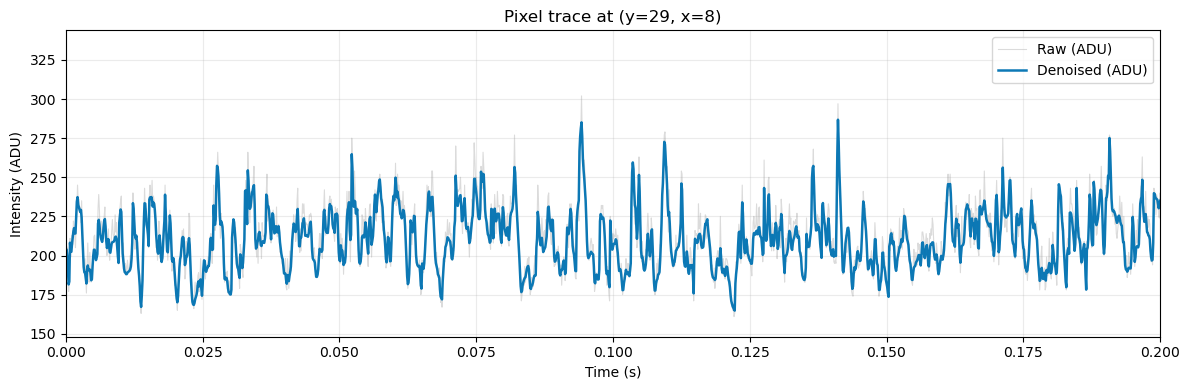

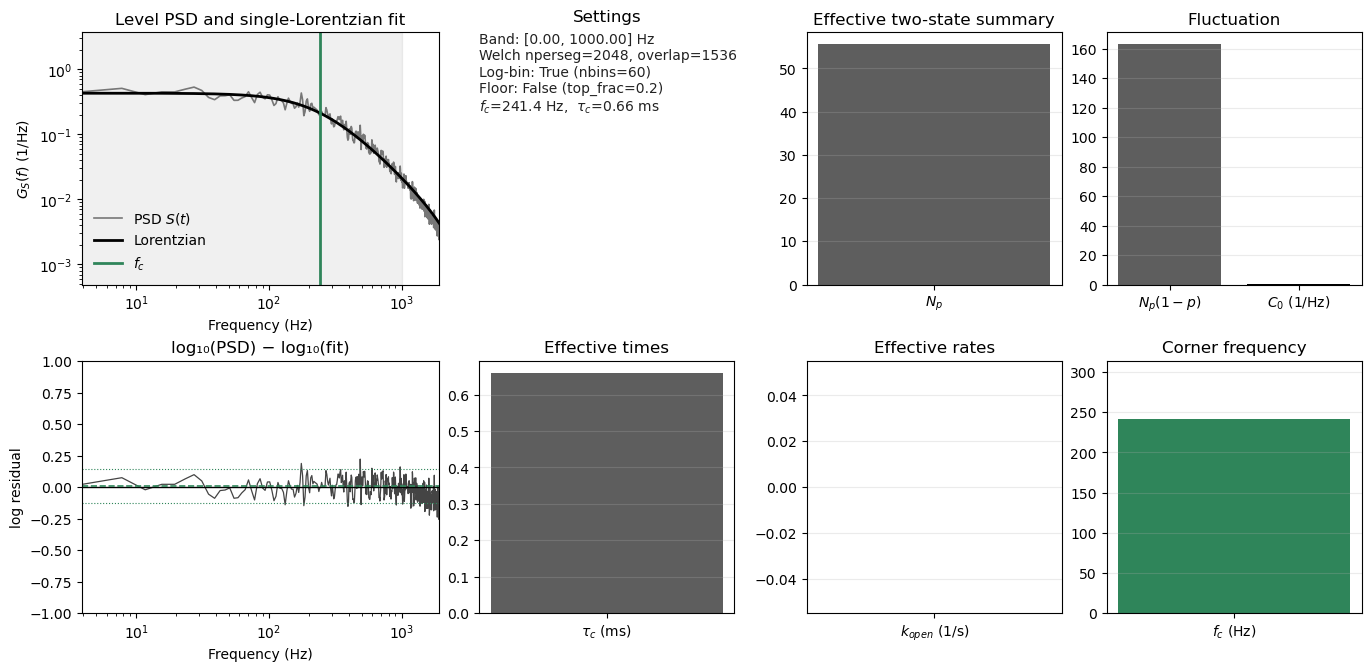

=== QC summary ===
Pass: True
Reasons: ()
R^2_log(1c) = 0.972
MAD_log(1c) = 0.047
Dynamic range = 1.30 decades
Corner freq fc = 241.37 Hz
tau_c = 0.66 ms
ΔR^2_log(2c - 1c) = -0.0013985735601553806
S-shape score = 0.01662573430849295
Multi-component suspected: False

=== Single-pixel summary ===
Pixel (y=29, x=8)
Mean counts Np       = 55.5
tau_c (PSD)          = 0.659 ms
Fluo-5 tau_dye       = 0.6 ms
R^2_log(1c)          = 0.972
MAD_log(1c)          = 0.047
Multi-component flag = False
QC ok                = True
Classification       = dye_only


In [16]:

# 1) Select pixel coordinates
y_coord = 29
x_coord = 8

# 2) Extract traces
y_raw = adu[:, y_coord, x_coord]         # raw ADU
y_den = adu_den[:, y_coord, x_coord]     # denoised ADU (visualization)
S_K   = counts_den[:, y_coord, x_coord]  # denoised counts (analysis signal)

# 3) Build time axis
fs = float(par["fs"])
t  = np.arange(len(S_K), dtype=float) / fs

# 4) Plot raw vs denoised trace
plt.figure(figsize=(12, 4))
ax = plt.gca()
ax.plot(t, y_raw, color=COL_RAW, lw=0.8, alpha=0.35, label="Raw (ADU)")
ax.plot(t, y_den, color=COL_DEN, lw=1.8, alpha=0.95, label="Denoised (ADU)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Intensity (ADU)")
ax.set_title(f"Pixel trace at (y={y_coord}, x={x_coord})")
ax.legend(loc="upper right")
ax.grid(alpha=0.25)

t_max = 0.2 if t[-1] >= 0.2 else t[-1]
ax.set_xlim(0.0, t_max)

plt.tight_layout()
plt.show()

# 5) PSD-based kinetic analysis on the denoised counts
res_pixel = run_uniform_psd_analysis(S_K, fs)
qc        = res_pixel["qc"]
kin       = res_pixel["kin"]

# ============================================================
# 6) Fluo-5 dye-blinking prior and pixel classification
# ============================================================

# Prior from isolated Fluo-5 dye measurements (from global DYE_PRIOR dict)
tau_dye_ms = float(DYE_PRIOR.get("tau_dye_ms", 0.60))          # ms
tol_rel    = float(DYE_PRIOR.get("tau_dye_rel_tol", 0.30))     # relative tolerance

tau_c_ms = float(qc.get("tau_c_ms", np.nan))
multi_mc = bool(qc.get("multi_component_suspected", False))
ok_fit   = bool(qc.get("ok", False))

classification = "undefined"

if ok_fit and np.isfinite(tau_c_ms):
    # Check compatibility of tau_c with the Fluo-5 prior
    if (abs(tau_c_ms - tau_dye_ms) <= tol_rel * tau_dye_ms) and not multi_mc:
        classification = "dye_only"
    elif multi_mc:
        classification = "dye_plus_extra"
    else:
        classification = "ambiguous"
else:
    classification = "low_snr_or_fit_failed"

print("\n=== Single-pixel summary ===")
print(f"Pixel (y={y_coord}, x={x_coord})")
print(f"Mean counts Np       = {kin.get('Np', np.nan):.3g}")
print(f"tau_c (PSD)          = {tau_c_ms:.3g} ms")
print(f"Fluo-5 tau_dye       = {tau_dye_ms:.3g} ms")
print(f"R^2_log(1c)          = {qc.get('r2_log_1c', np.nan):.3f}")
print(f"MAD_log(1c)          = {qc.get('mad_log_1c', np.nan):.3f}")
print(f"Multi-component flag = {multi_mc}")
print(f"QC ok                = {ok_fit}")
print(f"Classification       = {classification}")

# ============================================================
# 7) Optional: refine two-component fit if evidence for extra kinetics
# ============================================================

res2_pixel = None
if classification == "dye_plus_extra":
    # Refine the two-Lorentzian fit and generate the multi-panel plot
    res2_pixel = run_refine_if_two_components_and_plot(res_pixel)

# Parallelized spatial PSD maps: pixelwise kinetic inference and dye-blinking classification

This section extends the single-pixel PSD workflow into a **parallelized, full-field analysis** operating directly on the Poisson-consistent, Binlets-denoised photon field

$$
S(t,y,x) \quad \text{[counts/frame]}.
$$

Each spatial location $(y,x)$ is treated as an independent stochastic fluorescence trajectory.  
The same PSD-based kinetic inference described in the single-pixel analysis is applied to each pixel, enabling the construction of spatial maps of correlation amplitudes, correlation times, kinetic parameters, QC metrics, and dye-blinking classifications.

---

## Per-pixel PSD analysis

For every pixel $(y,x)$, the temporal trace

$$
S_{y,x}(t)=S(t,y,x)
$$

is analyzed as an isolated stochastic process.  
The PSD-based workflow consists of:

1. **Welch PSD and baseline subtraction**
   $$
   G_{\mathrm{c}}(f)=\max\!\left[G(f)-G_{\mathrm{floor}},\,\varepsilon\right].
   $$

2. **Discrete-time frequency correction**
   $$
   f_{\mathrm{eq}}
   =
   \frac{f_s}{\pi}\tan\!\left(\pi f / f_s\right).
   $$

3. **Log-binning** and restriction to the analysis band  
   $[f_{\min}, f_{\max}]$ 
   to isolate the Lorentzian roll-off and exclude drift and Nyquist artefacts.

4. **Single-Lorentzian PSD fit**
   $$
   G(f)=\frac{C_0}{1+(f/f_c)^2}, \qquad 
   \tau_c=\frac{1}{2\pi f_c}.
   $$

5. **Kinetic back-mapping**
   $$
   N_p=\langle S_{y,x}\rangle,
   $$
   $$
   N_p(1-p)=\frac{C_0}{4\,\tau_c},
   $$
   $$
   k_{\mathrm{open}}=\frac{p}{\tau_c}, \qquad
   k_{\mathrm{close}}=\frac{1-p}{\tau_c},
   $$
   $$
   \tau_{\mathrm{open}}=\frac{1}{k_{\mathrm{close}}}, \qquad
   \tau_{\mathrm{closed}}=\frac{1}{k_{\mathrm{open}}}.
   $$

Non-physical results (for example $p\notin[0,1]$, negative denominators, or non-finite values) are stored as $\mathrm{NaN}$ for all derived kinetics except $N_p$, $C_0$, and $\tau_c$.

---

## Dye-blinking prior and pixel classification

Calibration on isolated Fluo-5 molecules provides a reference blinking correlation time:

$$
\tau_{\text{dye}}, \qquad
f_{c,\text{dye}}=\frac{1}{2\pi\tau_{\text{dye}}}.
$$

The fitted correlation time $\tau_c$ at each pixel is compared against this reference:

- **Dye-only**  
  $$
  |\tau_c - \tau_{\text{dye}}| \le \mathrm{tol}\,\tau_{\text{dye}},
  $$
  with QC success and no multi-component evidence.

- **Dye + extra**  
  if QC indicates curvature, multi-scale structure, or single-Lorentzian inadequacy.

- **Ambiguous**  
  if $\tau_c$ is finite but QC criteria do not pass.

- **Low SNR / failed**  
  if PSD quality is insufficient (few in-band frequencies or low dynamic range).

These categories match those used in the single-pixel workflow.

---

## Optional two-component probe (recovery of the extra kinetic component)

Pixels not consistent with dye-only blinking undergo a coarse two-Lorentzian test:

$$
G_{2\mathrm{c}}(f)=
\frac{C_{0,\text{dye}}}{1+(f_{\mathrm{eq}}/f_{c,\text{dye}})^2}
+
\frac{C_{0,\text{extra}}}{1+(f_{\mathrm{eq}}/f_{c,\text{extra}})^2}.
$$

Here:

- the dye component is fixed (from isolated-dye calibration),
- the **extra component** \((C_{0,\text{extra}}, f_{c,\text{extra}})\) is fully free,
- the associated correlation time  
  $$
  \tau_{\text{extra}} = \frac{1}{2\pi f_{c,\text{extra}}}
  $$
  represents the **ion-channel–like correlated kinetics** we aim to recover.

Model improvement is evaluated via:

$$
\Delta R_{\log}^2, \qquad \Delta \mathrm{AICc},
$$

with negative $\Delta \mathrm{AICc}$ and increased $R^2_{\log}$ supporting the existence of an extra kinetic mode.

---

## Parallelized computation across all pixels

The function `run_psd_results_map` distributes pixel analyses across threads or processes:

- Each job contains  
  $$
  (y, x, S_{y,x}(t), f_s, \text{PSD parameters})
  $$
  and returns a full pixel-level result dictionary.

- The backend can be:
  - `"thread"` — safe for notebooks  
  - `"process"` — ideal for CPU-heavy PSD fitting

- The output objects are stored in  
  `results_map[y, x]`  
  and a boolean `fail_mask[y, x]` marks failed pixels.

Each pixel dictionary contains:

```python
{
    "C0": ...,
    "fc": ...,
    "tau_c": ...,
    "kin": {...},
    "qc": {...},
    "two_info": {...}   # only if two-component fit was applied
}
  ```
## Saving, loading, and assembling spatial maps

The spatial PSD results are stored as a $(y,x)$ object array.  
They can be saved and reloaded via:

- `save_results_map(results_map, path)`  
- `load_results_map(path)`

Scalar parameter fields are extracted using:

- `compute_parameter_maps(results_map)`

which produces spatial maps of:

- $C_0(y,x)$, $f_c(y,x)$, $\tau_c(y,x)$  
- $N_p(y,x)$, $N_c(y,x)$, $p(y,x)$  
- $k_{\mathrm{open}}(y,x)$, $k_{\mathrm{close}}(y,x)$  
- $\tau_{\mathrm{open}}(y,x)$, $\tau_{\mathrm{closed}}(y,x)$  
- QC indicators and multi-component flags  
- **extra-component kinetic maps**, when present:
  $$
  \bigl(C_{0,\mathrm{extra}},\; f_{c,\mathrm{extra}},\; \tau_{\mathrm{extra}}\bigr)
  $$

Missing or non-finite entries are stored as $\mathrm{NaN}$.

---

## Interpretation of spatial PSD maps

These maps provide a quantitative, spatially resolved picture of fluorescence dynamics:

- **Dye-only regions** — spectra explained entirely by Fluo-5 blinking  
- **Dye + extra regions** — presence of additional correlated processes  
  (Ca$^{2+}$ microdomains, buffering kinetics, or channel-like fluctuations)  
- **Ambiguous regions** — finite correlation times but weak QC  
- **Low SNR regions** — insufficient spectral information

Because each pixel is analyzed with the same PSD model, the resulting maps are reproducible, scalable, and directly comparable with the single-pixel analysis.

In [17]:
# ============================================================
# PSD results-per-pixel (object map) + save/load + map extraction
# ============================================================

import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, as_completed
from typing import Callable, Dict, Tuple, Any, Optional

# ------------------------------------------------------------
# Derive default output paths from an image path
# ------------------------------------------------------------
def _derive_default_paths(img_path: str) -> Tuple[str, str]:
    """
    Given /a/b/c/roi_00_ctr.ome.tif
    → (/a/b/c/roi_00_ctr__psd_resmap.npy, /a/b/c/roi_00_ctr__psd_maps.npz)
    """
    d, base = os.path.split(os.path.abspath(img_path))
    stem = base
    for suf in (".ome.tif", ".tif", ".tiff", ".nii.gz", ".nii", ".npy", ".npz"):
        if stem.lower().endswith(suf):
            stem = stem[: -len(suf)]
            break
    resmap_path = os.path.join(d, f"{stem}__psd_resmap.npy")
    maps_path   = os.path.join(d, f"{stem}__psd_maps.npz")
    return resmap_path, maps_path


# ------------------------------------------------------------
# Worker: returns the FULL per-pixel result dictionary
# ------------------------------------------------------------
def _psd_pixel_worker_full(job: Tuple[int, int, np.ndarray, float,
                                      Callable[..., Dict[str, Any]],
                                      Dict[str, Any]]):
    """
    job: (yy, xx, S_K, fs, analyze_fn, psd_params)
    returns: (yy, xx, failed: bool, res_dict_or_None)
    """
    yy, xx, S_K, fs, analyze_fn, psd_params = job

    # Merge user parameters with enforced defaults for map building
    kwargs = dict(psd_params or {})
    kwargs.setdefault("fs", fs)
    kwargs.setdefault("make_plot", False)

    try:
        res = analyze_fn(S_K, **kwargs)
        if not isinstance(res, dict):
            return yy, xx, True, None
        return yy, xx, False, res
    except Exception:
        return yy, xx, True, None


# ------------------------------------------------------------
# Run PSD analysis to produce a results-per-pixel object map
# ------------------------------------------------------------
def run_psd_results_map(
    S_vol: np.ndarray,
    *,
    fs: float,
    analyze_fn: Callable[..., Dict[str, Any]],
    psd_params: Optional[Dict[str, Any]] = None,
    n_workers: Optional[int] = None,
    backend: str = "thread",   # "thread" is safe in notebooks; "process" for heavy CPU
    progress: bool = False
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Apply analyze_fn to every pixel of S_vol (t, y, x) and return an object array

        results_map[y, x] = dict produced by analyze_fn(S_K, **psd_params)

    Parameters
    ----------
    S_vol : ndarray, shape (t, y, x)
        Denoised counts per frame.
    fs : float
        Sampling frequency (Hz).
    analyze_fn : callable
        Function implementing the single-pixel PSD analysis. It must return
        a dictionary with at least the keys:
            "C0", "tau_c" (and optionally "fc"),
            "kin" : dict with kinetic parameters,
            "qc"  : dict with QC metrics.
        Optionally, it can include an "extra" dict for the second component:
            res["extra"] = {
                "C0": ...,
                "tau_c": ...,
                "fc": ...,
                "kin": {Nc, p, Np, ...}   # same schema as main "kin"
            }
    psd_params : dict, optional
        Additional keyword arguments forwarded to analyze_fn.
    n_workers : int or None
        Number of worker threads or processes. None uses a default.
    backend : {"thread","process"}
        Parallelization backend.
    progress : bool
        If True, print simple progress updates.

    Returns
    -------
    results_map : ndarray of object, shape (y, x)
        Per-pixel result dictionaries (None on failure).
    fail_mask : ndarray of bool, shape (y, x)
        True where analysis failed or raised an exception.
    """
    if S_vol.ndim != 3:
        raise ValueError("S_vol must have shape (t, y, x).")
    _, y_size, x_size = S_vol.shape

    results_map = np.empty((y_size, x_size), dtype=object)
    fail_mask   = np.zeros((y_size, x_size), dtype=bool)

    # Freeze parameters once
    psd_params_frozen = dict(psd_params or {})

    # Build jobs
    jobs = [
        (yy, xx, np.asarray(S_vol[:, yy, xx], dtype=float), fs, analyze_fn, psd_params_frozen)
        for yy in range(y_size) for xx in range(x_size)
    ]

    Executor = ThreadPoolExecutor if backend == "thread" else ProcessPoolExecutor
    total = len(jobs)
    step = max(1, total // 20)  # approximately 5 percent progress tick

    with Executor(max_workers=n_workers) as ex:
        futures = [ex.submit(_psd_pixel_worker_full, job) for job in jobs]
        done = 0
        for fut in as_completed(futures):
            yy, xx, failed, res = fut.result()
            if failed or (res is None):
                fail_mask[yy, xx] = True
                results_map[yy, xx] = None
            else:
                results_map[yy, xx] = res
            if progress:
                done += 1
                if (done % step) == 0 or done == total:
                    print(f"[run_psd_results_map] {done}/{total} pixels")

    return results_map, fail_mask


# ------------------------------------------------------------
# Save / load the results map
# ------------------------------------------------------------
def save_results_map(results_map: np.ndarray, path: str) -> None:
    """
    Persist the (y, x) object array of dicts.
    Uses .npy with allow_pickle=True.
    """
    np.save(path, results_map, allow_pickle=True)

def load_results_map(path: str) -> np.ndarray:
    """
    Load the (y, x) object array of dicts produced by save_results_map.
    """
    arr = np.load(path, allow_pickle=True)
    if arr.dtype != object:
        raise ValueError("Loaded array is not an object array.")
    return arr


# ------------------------------------------------------------
# Extract parameter and classification maps from results_map
# ------------------------------------------------------------
def compute_parameter_maps(results_map: np.ndarray) -> Dict[str, np.ndarray]:
    """
    Convert a (y, x) object array of PSD results into scalar parameter
    and classification maps.

    Expected per-pixel dict structure (as produced by analyze_level_psd_onecomponent):

      Top-level PSD and kinetics:
        res["C0"], res["tau_c"], optional res["fc"]
        res["kin"]: dict with keys
            "Nc","p","Np","Np1mp","k_open","k_close","tau_open","tau_closed","fc"
        res["qc"]: dict with at least
            "ok": bool,
            "multi_component_suspected": bool,
            optional "tau_c_ms": correlation time in ms

      Optional second component (ion-channel related, when present):
        res["extra"] : dict with the same schema
            "C0", "tau_c", optional "fc",
            "kin": {...}   # Nc, p, Np, etc. for the second component

    Outputs NaN where the pixel result is None or fields are missing.

    Classification logic per pixel (same as single-pixel example):

        tau_dye_ms = DYE_PRIOR["tau_dye_ms"]
        tol_rel    = DYE_PRIOR["tau_dye_rel_tol"]
        tau_c_ms   = qc["tau_c_ms"]
        multi_mc   = qc["multi_component_suspected"]
        ok_fit     = qc["ok"]

        if ok_fit and finite(tau_c_ms):
            if |tau_c_ms - tau_dye_ms| <= tol_rel * tau_dye_ms
               and not multi_mc:
                class = "dye_only"
            elif multi_mc:
                class = "dye_plus_extra"
            else:
                class = "ambiguous"
        else:
            class = "low_snr_or_fit_failed"
    """
    if results_map.ndim != 2 or results_map.dtype != object:
        raise ValueError("results_map must be a (y, x) object array of dicts.")

    y_size, x_size = results_map.shape

    # Fluo-5 prior (global configuration)
    tau_dye_ms = float(DYE_PRIOR.get("tau_dye_ms", 0.60))
    tol_rel    = float(DYE_PRIOR.get("tau_dye_rel_tol", 0.30))

    # Integer codes for class map
    CLASS_CODES = dict(
        undefined=0,
        dye_only=1,
        dye_plus_extra=2,
        ambiguous=3,
        low_snr_or_fit_failed=4,
    )

    MAP_KEYS = (
        # Main component (dye-dominated)
        "C0", "fc", "tau_c", "tau_c_ms",
        "Nc", "p", "Np", "Np1mp",
        "k_open", "k_close", "tau_open", "tau_closed",
        # Second component (extra, ion-channel related)
        "C0_extra", "fc_extra", "tau_c_extra", "tau_c_ms_extra",
        "Nc_extra", "p_extra", "Np_extra", "Np1mp_extra",
        "k_open_extra", "k_close_extra",
        "tau_open_extra", "tau_closed_extra",
        # QC and classification
        "qc_ok", "multi_component_suspected",
        "class_code",
        "dye_only", "dye_plus_extra",
        "ambiguous", "low_snr_or_fit_failed",
    )

    maps = {k: np.full((y_size, x_size), np.nan, dtype=float) for k in MAP_KEYS}

    for yy in range(y_size):
        row = results_map[yy]
        for xx in range(x_size):
            res = row[xx]
            if not isinstance(res, dict):
                continue

            # ===================== main component =====================
            C0    = res.get("C0", np.nan)
            tau_c = res.get("tau_c", np.nan)
            fc_tl = res.get("fc", np.nan)

            kin = res.get("kin", {}) or {}
            fc_kin = kin.get("fc", np.nan)

            # Choose fc (prefer top-level if finite)
            fc = fc_tl if np.isfinite(fc_tl) else fc_kin

            qc = res.get("qc", {}) or {}
            qc_ok  = bool(qc.get("ok", False))
            mc_sus = bool(qc.get("multi_component_suspected", False))
            tau_c_ms = qc.get("tau_c_ms", np.nan)

            # Assign main PSD parameters
            maps["C0"][yy, xx]       = float(C0)       if np.isfinite(C0)       else np.nan
            maps["tau_c"][yy, xx]    = float(tau_c)    if np.isfinite(tau_c)    else np.nan
            maps["fc"][yy, xx]       = float(fc)       if np.isfinite(fc)       else np.nan
            maps["tau_c_ms"][yy, xx] = float(tau_c_ms) if np.isfinite(tau_c_ms) else np.nan

            # Assign main kinetic parameters
            for k in ("Nc", "p", "Np", "Np1mp",
                      "k_open", "k_close", "tau_open", "tau_closed"):
                v = kin.get(k, np.nan)
                maps[k][yy, xx] = float(v) if np.isfinite(v) else np.nan

            # QC flags
            maps["qc_ok"][yy, xx]                     = 1.0 if qc_ok  else 0.0
            maps["multi_component_suspected"][yy, xx] = 1.0 if mc_sus else 0.0

            # ===================== extra component =====================
            # Optional second Lorentzian (e.g. ion-channel kinetics)
            extra = res.get("extra", {}) or {}
            if isinstance(extra, dict) and extra:
                C0_e    = extra.get("C0", np.nan)
                tau_c_e = extra.get("tau_c", np.nan)
                fc_e_tl = extra.get("fc", np.nan)

                kin_e = extra.get("kin", {}) or {}
                fc_e_kin = kin_e.get("fc", np.nan)

                fc_e = fc_e_tl if np.isfinite(fc_e_tl) else fc_e_kin

                tau_c_ms_e = extra.get("tau_c_ms", np.nan)

                maps["C0_extra"][yy, xx]       = float(C0_e)       if np.isfinite(C0_e)       else np.nan
                maps["tau_c_extra"][yy, xx]    = float(tau_c_e)    if np.isfinite(tau_c_e)    else np.nan
                maps["fc_extra"][yy, xx]       = float(fc_e)       if np.isfinite(fc_e)       else np.nan
                maps["tau_c_ms_extra"][yy, xx] = float(tau_c_ms_e) if np.isfinite(tau_c_ms_e) else np.nan

                for k in ("Nc", "p", "Np", "Np1mp",
                          "k_open", "k_close", "tau_open", "tau_closed"):
                    v = kin_e.get(k, np.nan)
                    maps[f"{k}_extra"][yy, xx] = float(v) if np.isfinite(v) else np.nan

            # ===================== classification =====================
            class_label = "undefined"

            if qc_ok and np.isfinite(tau_c_ms):
                if (abs(tau_c_ms - tau_dye_ms) <= tol_rel * tau_dye_ms) and (not mc_sus):
                    class_label = "dye_only"
                elif mc_sus:
                    class_label = "dye_plus_extra"
                else:
                    class_label = "ambiguous"
            else:
                class_label = "low_snr_or_fit_failed"

            code = CLASS_CODES[class_label]

            maps["class_code"][yy, xx] = float(code)
            maps["dye_only"][yy, xx]               = 1.0 if class_label == "dye_only" else 0.0
            maps["dye_plus_extra"][yy, xx]         = 1.0 if class_label == "dye_plus_extra" else 0.0
            maps["ambiguous"][yy, xx]              = 1.0 if class_label == "ambiguous" else 0.0
            maps["low_snr_or_fit_failed"][yy, xx]  = 1.0 if class_label == "low_snr_or_fit_failed" else 0.0

    return maps


# ------------------------------------------------------------
# Save maps as .npz (one array per key)
# ------------------------------------------------------------
def save_maps_npz(maps: Dict[str, np.ndarray], path: str) -> None:
    """
    Save parameter maps to a compressed .npz:
        np.load(path) → dict-like with the same keys.
    """
    np.savez_compressed(path, **maps)



In [18]:

# ============================================================
# Example configuration and execution for map building
# ============================================================

PSD_MAP_PARAMS = PSD_ANALYSIS_PARAMS.copy()
PSD_MAP_PARAMS.update(dict(
    make_plot=False,        # disable plotting inside the per-pixel analysis
))

# 1) Derive default output paths from an image path
resmap_path, maps_path = _derive_default_paths(img_path)

# 2) Run PSD analysis per pixel (object map, no I/O)
results_map, fail_mask = run_psd_results_map(
    S_vol=counts_den,
    fs=PSD_MAP_PARAMS["fs"],
    analyze_fn=analyze_level_psd_onecomponent,
    psd_params=PSD_MAP_PARAMS,
    n_workers=None,
    backend="thread",
    progress=True
)

# 3) Save when desired
save_results_map(results_map, resmap_path)

# 4) Reload later (if needed)
results_map_loaded = load_results_map(resmap_path)

# 5) Compute parameter and classification maps from the results map
maps = compute_parameter_maps(results_map_loaded)

# 6) Optionally persist the maps
save_maps_npz(maps, maps_path)

[run_psd_results_map] 204/4096 pixels
[run_psd_results_map] 408/4096 pixels
[run_psd_results_map] 612/4096 pixels
[run_psd_results_map] 816/4096 pixels
[run_psd_results_map] 1020/4096 pixels
[run_psd_results_map] 1224/4096 pixels
[run_psd_results_map] 1428/4096 pixels
[run_psd_results_map] 1632/4096 pixels
[run_psd_results_map] 1836/4096 pixels
[run_psd_results_map] 2040/4096 pixels
[run_psd_results_map] 2244/4096 pixels
[run_psd_results_map] 2448/4096 pixels
[run_psd_results_map] 2652/4096 pixels
[run_psd_results_map] 2856/4096 pixels
[run_psd_results_map] 3060/4096 pixels
[run_psd_results_map] 3264/4096 pixels
[run_psd_results_map] 3468/4096 pixels
[run_psd_results_map] 3672/4096 pixels
[run_psd_results_map] 3876/4096 pixels
[run_psd_results_map] 4080/4096 pixels
[run_psd_results_map] 4096/4096 pixels


# Visualization of Spatial PSD Maps in Napari

This section provides a visualization interface for inspecting all PSD-derived spatial maps, including:

- Lorentzian parameters:  
  - $C_0$, $f_c$, $\tau_c$
- Kinetic quantities:  
  - $N_p$, $N_c$, $p$  
  - $k_{\mathrm{open}}$, $k_{\mathrm{close}}$  
  - $\tau_{\mathrm{open}}$, $\tau_{\mathrm{closed}}$
- Fluctuation strength:  
  - $N_p(1-p)$, $C_0$
- QC indicators:  
  - `qc_ok`
- Multi-component evidence:  
  - `multi_component_suspected`
- **Extra-component kinetics** (if present):  
  $$
  C_{0,\mathrm{extra}},\quad f_{c,\mathrm{extra}},\quad \tau_{\mathrm{extra}}
  $$
- Pixel classification labels:  
  - $0 =$ undefined / low SNR  
  - $1 =$ dye-only  
  - $2 =$ dye + extra  
  - $3 =$ ambiguous

All maps are displayed as translucent Napari layers, each with an automatically selected colormap and contrast limits based on robust percentiles.

---

## Features

### 1. Automatic scientific grouping

Each parameter is associated with a scientific category:

- **Kinetics**: `k_open`, `k_close`, `tau_open`, `tau_closed`  
- **Population**: `Nc`, `p`, `Np`  
- **Fluctuation**: `Np1mp`, `C0`  
- **Correlation**: `tau_c`, `fc`  
- **QC**: `qc_ok`  
- **Multi-component**: `multi_component_suspected`  
- **Extra component**: `C0_extra`, `fc_extra`, `tau_extra`  
- **Classification**: `classification_label`

Each category receives its own colormap.

---

## 2. Robust contrast limits

For each parameter map, limits are set using the 2nd–98th percentiles of finite values, excluding outliers. Binary/categorical maps have fixed limits.

---

## 3. Napari display

Calling:

```python
viewer, stack, names, cmaps, clims, meta = show_maps_in_napari_layers(maps)
```
opens a Napari viewer with one layer per parameter. Each layer:
	•	has translucent blending (opacity ≈ 0.85)
	•	is labeled with its parameter name
	•	stores metadata for scientific context
	•	includes a legend summarizing all LUT mappings

In [19]:
import numpy as np

# ---------------------------------------------------------------------
# Parameter set (includes QC + multi-component diagnostic channels)
# ---------------------------------------------------------------------
PSD_MAP_KEYS = (
    "C0", "fc", "tau_c",
    "Nc", "p", "Np", "Np1mp",
    "k_open", "k_close", "tau_open", "tau_closed",
    "C0_extra", "fc_extra", "tau_extra",
    "qc_ok", "multi_component_suspected",
    "classification_label",
)

# ---------------------------------------------------------------------
# Scientific grouping with LUT assignments
# ---------------------------------------------------------------------
PARAM_GROUPS = {
    "kinetics":        ("k_open", "k_close", "tau_open", "tau_closed"),
    "population":      ("Nc", "p", "Np"),
    "fluctuation":     ("Np1mp", "C0"),
    "correlation":     ("tau_c", "fc"),
    "extra":           ("C0_extra", "fc_extra", "tau_extra"),
    "qc":              ("qc_ok",),
    "multicomponent":  ("multi_component_suspected",),
    "classification":  ("classification_label",),
}

# Use only colormaps that Napari reports as available in your error message
GROUP_COLORMAP = {
    "kinetics":       "magma",
    "population":     "viridis",
    "fluctuation":    "inferno",
    "correlation":    "cividis",
    "extra":          "turbo",    # was "rocket" → replaced by a standard colormap
    "qc":             "Greys",
    "multicomponent": "plasma",
    "classification": "tab20",
}

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def _map_to_group(param: str) -> str:
    """
    Map a parameter name to its scientific group.
    """
    for g, keys in PARAM_GROUPS.items():
        if param in keys:
            return g
    return "population"

def _robust_limits(arr: np.ndarray, param: str) -> tuple[float, float]:
    """
    Compute robust display limits based on the 2nd and 98th percentiles.
    Special cases:
      - Binary / categorical parameters: fixed [0, 1] or [0, 3].
      - Probabilities: clipped to [0, 1].
      - Rates and positive-definite parameters: lower bound forced to ≥ 0.
    """
    a = np.asarray(arr, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        # Fallback
        if param == "classification_label":
            return (0.0, 3.0)
        return (0.0, 1.0)

    # Binary maps
    if param in {"qc_ok", "multi_component_suspected"}:
        return (0.0, 1.0)

    # Categorical classification: 0,1,2,3
    if param == "classification_label":
        return (0.0, 3.0)

    p2, p98 = np.nanpercentile(a, [2.0, 98.0])

    positive_like = {
        "k_open", "k_close", "C0", "fc", "tau_c",
        "tau_open", "tau_closed", "Np", "Nc", "Np1mp",
        "C0_extra", "fc_extra", "tau_extra",
    }

    if param in positive_like:
        lo = max(0.0, p2)
        hi = max(lo + np.finfo(float).eps, p98)
        return (lo, hi)

    if param == "p":
        lo = max(0.0, min(1.0, p2))
        hi = max(lo + 1e-6, min(1.0, p98))
        return (lo, hi)

    lo = p2
    hi = max(lo + np.finfo(float).eps, p98)
    return (lo, hi)

def build_maps_stack(
    maps: dict,
    order: tuple = PSD_MAP_KEYS,
    dtype=np.float32,
    fill_value=np.nan,
) -> tuple[np.ndarray, list[str]]:
    """
    Stack all requested parameter maps into a 3D array with shape (C, Y, X).

    Parameters
    ----------
    maps : dict
        Dictionary of 2D arrays (Y, X) keyed by parameter names.
    order : tuple
        Ordered list of parameter names to include.
    dtype : data-type
        Output data type.
    fill_value : float
        Value used where a requested parameter is missing.

    Returns
    -------
    stack : ndarray
        Array of shape (C, Y, X) with C = len(order).
    names : list of str
        Names of the channels in the same order as the stack axis.
    """
    present = [k for k in order if k in maps]
    if not present:
        raise ValueError("No valid map keys found in 'maps'.")

    Y, X = np.asarray(maps[present[0]]).shape
    stack = np.full((len(order), Y, X), fill_value, dtype=dtype)

    for ci, key in enumerate(order):
        if key in maps:
            arr = np.asarray(maps[key], dtype=dtype)
            if arr.shape != (Y, X):
                raise ValueError(
                    f"Shape mismatch for key '{key}': {arr.shape} != {(Y, X)}"
                )
            stack[ci] = arr

    return stack, list(order)

def make_channel_styles(maps: dict, order: tuple = PSD_MAP_KEYS):
    """
    Compute colormap, contrast limits, and metadata for each parameter.
    """
    cmaps, clims, meta = [], [], []
    for key in order:
        group = _map_to_group(key)
        cmap_name = GROUP_COLORMAP.get(group, "viridis")
        cmaps.append(cmap_name)

        if key in maps:
            vmin, vmax = _robust_limits(maps[key], key)
        else:
            vmin, vmax = (0.0, 1.0)

        clims.append((float(vmin), float(vmax)))
        meta.append({
            "parameter": key,
            "group": group,
            "description": (
                "Kinetics" if group == "kinetics" else
                "Population behavior" if group == "population" else
                "Fluctuation strength" if group == "fluctuation" else
                "Temporal correlation" if group == "correlation" else
                "Extra Lorentzian component (channels)" if group == "extra" else
                "Quality control (1=pass, 0=fail)" if group == "qc" else
                "Multi-component suspicion (1=suspected, 0=not suspected)" if group == "multicomponent" else
                "Pixel classification label (0=undefined, 1=dye-only, 2=dye+extra, 3=ambiguous)"
            ),
        })
    return cmaps, clims, meta

# ---------------------------------------------------------------------
# Napari display: one layer per parameter, translucent blending
# ---------------------------------------------------------------------
def show_maps_in_napari_layers(
    maps: dict,
    *,
    order: tuple = PSD_MAP_KEYS,
    dtype=np.float32,
    fill_value=np.nan,
    layer_prefix: str = "PSD",
    default_opacity: float = 0.85,
):
    """
    Display PSD-derived parameter maps as separate Napari image layers.

    Parameters
    ----------
    maps : dict
        Dictionary of 2D arrays (Y, X) keyed by parameter names.
    order : tuple
        Parameter names to display and their ordering along the channel axis.
    dtype : data-type
        Data type for the internal stack.
    fill_value : float
        Value used for missing parameters.
    layer_prefix : str
        Prefix for Napari layer names.
    default_opacity : float
        Opacity for all layers (0–1), using translucent blending.

    Returns
    -------
    viewer : napari.Viewer
    stack : ndarray
        Stacked array of shape (C, Y, X).
    names : list of str
        Names of parameters (one per channel).
    cmaps : list of str
        Colormap names per channel.
    clims : list of (vmin, vmax)
        Contrast limits per channel.
    meta : list of dict
        Metadata with parameter name, group, and description.
    """
    stack, names = build_maps_stack(maps, order=order, dtype=dtype, fill_value=fill_value)
    cmaps, clims, meta = make_channel_styles(maps, order=order)

    try:
        import napari
    except Exception as e:
        raise RuntimeError("napari is required. Install with `pip install napari`.") from e

    viewer = napari.Viewer()

    def _ensure_unique(name_base: str) -> str:
        name = name_base
        i = 1
        existing = {ly.name for ly in viewer.layers}
        while name in existing:
            i += 1
            name = f"{name_base} ({i})"
        return name

    for ci, cname in enumerate(names):
        layer_name = _ensure_unique(f"{layer_prefix}: {cname}")
        layer = viewer.add_image(
            stack[ci],
            name=layer_name,
            colormap=cmaps[ci],
            contrast_limits=clims[ci],
            blending="translucent",
            opacity=float(default_opacity),
            metadata={**meta[ci], "index": ci},
        )
        layer.gamma = 1.0
        layer.visible = True

    legend = (
        "LUT mapping:\n"
        f"  Kinetics → {GROUP_COLORMAP['kinetics']}: k_open, k_close, tau_open, tau_closed\n"
        f"  Population → {GROUP_COLORMAP['population']}: Nc, p, Np\n"
        f"  Fluctuation → {GROUP_COLORMAP['fluctuation']}: Np(1-p), C0\n"
        f"  Correlation → {GROUP_COLORMAP['correlation']}: tau_c, fc\n"
        f"  Extra component → {GROUP_COLORMAP['extra']}: C0_extra, fc_extra, tau_extra\n"
        f"  Quality control → {GROUP_COLORMAP['qc']}: qc_ok (1=pass, 0=fail)\n"
        f"  Multi-component → {GROUP_COLORMAP['multicomponent']}: multi_component_suspected (1=suspected, 0=not)\n"
        f"  Classification → {GROUP_COLORMAP['classification']}: classification_label (0=undef, 1=dye-only, 2=dye+extra, 3=ambiguous)"
    )
    try:
        viewer.text_overlay.visible = True
        viewer.text_overlay.text = legend
        viewer.text_overlay.position = (10, 10)
    except Exception:
        pass

    return viewer, stack, names, cmaps, clims, meta

In [20]:
# Assume 'maps' is the output of compute_parameter_maps(results_map_loaded)
# Example:
# maps = compute_parameter_maps(results_map_loaded)

# Show in Napari
viewer, stack, names, cmaps, clims, meta = show_maps_in_napari_layers(
    maps,
    order=PSD_MAP_KEYS,
    dtype=np.float32,
    fill_value=np.nan,
    layer_prefix="PSD",
    default_opacity=1,
)

print("Displayed parameters:")
for name in names:
    print(" -", name)

Displayed parameters:
 - C0
 - fc
 - tau_c
 - Nc
 - p
 - Np
 - Np1mp
 - k_open
 - k_close
 - tau_open
 - tau_closed
 - C0_extra
 - fc_extra
 - tau_extra
 - qc_ok
 - multi_component_suspected
 - classification_label


# Debugging

In [21]:
import numpy as np

# ============================================================
# Minimal PSD summary maps: single-component + extra component
# ============================================================

# ---------------------------------------------------------------------
# Parameter set (summary only)
# ---------------------------------------------------------------------
PSD_MAP_KEYS = (
    "Np",                 # mean counts (single component)
    "tau_c_ms",           # single-component correlation time [ms]
    "r2_log_1c",          # log-space R^2 of 1c fit
    "mad_log_1c",         # log-space MAD of residuals
    "qc_ok",              # 1 = QC passed
    "multi_component_suspected",  # 1 = extra component suspected
    "classification_code",        # 0..4 (dye_only, dye+extra, etc.)
    "C0_extra",           # amplitude of extra component
    "fc_extra",           # corner frequency of extra component [Hz]
    "tau_extra_ms",       # correlation time of extra component [ms]
    "Np_extra",           # effective brightness in extra component
    "Nc_extra",           # effective emitter count for extra component
)

# ---------------------------------------------------------------------
# Scientific grouping with LUT assignments (simplified)
# ---------------------------------------------------------------------
PARAM_GROUPS = {
    "brightness": ("Np", "Np_extra"),
    "timescale":  ("tau_c_ms", "tau_extra_ms"),
    "quality":    ("r2_log_1c", "mad_log_1c", "qc_ok", "multi_component_suspected"),
    "extra":      ("C0_extra", "fc_extra", "Nc_extra"),
    "class":      ("classification_code",),
}

GROUP_COLORMAP = {
    "brightness": "viridis",
    "timescale":  "magma",
    "quality":    "cividis",
    "extra":      "inferno",
    "class":      "tab20",
}

# ---------------------------------------------------------------------
# Helper: extract summary maps from results_map
# ---------------------------------------------------------------------
def compute_parameter_maps(results_map: np.ndarray) -> dict:
    """
    Convert a (y, x) object array of PSD results into a minimal
    set of summary maps, closely matching the single-pixel output.

    Expected per-pixel dict structure:
      - res["kin"]:    {"Np", ...}
      - res["qc"]:     {"ok", "tau_c_ms", "r2_log_1c", "mad_log_1c",
                        "multi_component_suspected", 
                        "classification" or "classification_code"}
      - res["extra"]:  {"C0_extra", "fc_extra", "tau_extra_ms",
                        "Np_extra", "Nc_extra"}  (only when extra component used)

    All missing or non-finite entries are stored as NaN.
    """
    if results_map.ndim != 2 or results_map.dtype != object:
        raise ValueError("results_map must be a (y, x) object array of dicts.")

    y_size, x_size = results_map.shape
    maps = {k: np.full((y_size, x_size), np.nan, dtype=float) for k in PSD_MAP_KEYS}

    # Mapping from classification string to code
    CLASS_CODE = {
        "dye_only": 1.0,
        "dye_plus_extra": 2.0,
        "ambiguous": 3.0,
        "low_snr_or_fit_failed": 4.0,
    }

    for yy in range(y_size):
        row = results_map[yy]
        for xx in range(x_size):
            res = row[xx]
            if not isinstance(res, dict):
                continue

            kin   = res.get("kin", {}) or {}
            qc    = res.get("qc", {})  or {}
            extra = res.get("extra", res.get("two_extra", {})) or {}

            # --- Single-component brightness ---
            Np = kin.get("Np", np.nan)
            if np.isfinite(Np):
                maps["Np"][yy, xx] = float(Np)

            # --- Single-component correlation time (ms) ---
            tau_c_ms = qc.get("tau_c_ms", np.nan)
            if not np.isfinite(tau_c_ms):
                # Fallback: convert tau_c [s] if present
                tau_c = res.get("tau_c", np.nan)
                if np.isfinite(tau_c):
                    tau_c_ms = 1e3 * float(tau_c)
            if np.isfinite(tau_c_ms):
                maps["tau_c_ms"][yy, xx] = float(tau_c_ms)

            # --- Quality metrics ---
            r2  = qc.get("r2_log_1c", np.nan)
            mad = qc.get("mad_log_1c", np.nan)
            if np.isfinite(r2):
                maps["r2_log_1c"][yy, xx] = float(r2)
            if np.isfinite(mad):
                maps["mad_log_1c"][yy, xx] = float(mad)

            qc_ok = 1.0 if bool(qc.get("ok", False)) else 0.0
            maps["qc_ok"][yy, xx] = qc_ok

            mc_sus = 1.0 if bool(qc.get("multi_component_suspected", False)) else 0.0
            maps["multi_component_suspected"][yy, xx] = mc_sus

            # --- Classification code ---
            cls_code = qc.get("classification_code", np.nan)
            if not np.isfinite(cls_code):
                cls_str = qc.get("classification", "")
                cls_code = CLASS_CODE.get(cls_str, 0.0)
            maps["classification_code"][yy, xx] = float(cls_code)

            # --- Extra-component parameters (if present) ---
            C0_extra = extra.get("C0_extra", np.nan)
            if np.isfinite(C0_extra):
                maps["C0_extra"][yy, xx] = float(C0_extra)

            fc_extra = extra.get("fc_extra", np.nan)
            if np.isfinite(fc_extra):
                maps["fc_extra"][yy, xx] = float(fc_extra)

            tau_extra_ms = extra.get("tau_extra_ms", np.nan)
            if not np.isfinite(tau_extra_ms):
                tau_extra = extra.get("tau_extra", np.nan)
                if np.isfinite(tau_extra):
                    tau_extra_ms = 1e3 * float(tau_extra)
            if np.isfinite(tau_extra_ms):
                maps["tau_extra_ms"][yy, xx] = float(tau_extra_ms)

            Np_extra = extra.get("Np_extra", np.nan)
            if np.isfinite(Np_extra):
                maps["Np_extra"][yy, xx] = float(Np_extra)

            Nc_extra = extra.get("Nc_extra", np.nan)
            if np.isfinite(Nc_extra):
                maps["Nc_extra"][yy, xx] = float(Nc_extra)

    return maps

# ---------------------------------------------------------------------
# Helpers (updated to understand new keys)
# ---------------------------------------------------------------------
def _map_to_group(param: str) -> str:
    for g, keys in PARAM_GROUPS.items():
        if param in keys:
            return g
    return "brightness"

def _robust_limits(arr: np.ndarray, param: str) -> tuple[float, float]:
    a = np.asarray(arr, float)
    a = a[np.isfinite(a)]
    if a.size == 0:
        return (0.0, 1.0)

    # Binary or categorical-like maps
    if param in {"qc_ok", "multi_component_suspected"}:
        return (0.0, 1.0)
    if param == "classification_code":
        lo = np.nanmin(a)
        hi = np.nanmax(a)
        return (float(lo) - 0.5, float(hi) + 0.5)

    # Continuous maps: use robust percentiles
    p2, p98 = np.nanpercentile(a, [2.0, 98.0])

    if param in {
        "Np", "Np_extra",
        "C0_extra", "fc_extra",
        "Nc_extra",
        "tau_c_ms", "tau_extra_ms",
        "r2_log_1c", "mad_log_1c",
    }:
        lo = max(0.0, p2)
        hi = max(lo + np.finfo(float).eps, p98)
        return (lo, hi)

    lo = p2
    hi = max(lo + np.finfo(float).eps, p98)
    return (lo, hi)

# The rest of the visualization helpers (build_maps_stack, make_channel_styles,
# show_maps_in_napari_layers) remain the same, except for the legend text in
# show_maps_in_napari_layers. Replace the legend string with:
def make_channel_styles(maps: dict, order: tuple = PSD_MAP_KEYS):
    cmaps, clims, meta = [], [], []
    for key in order:
        group = _map_to_group(key)
        cmaps.append(GROUP_COLORMAP.get(group, "viridis"))
        if key in maps:
            vmin, vmax = _robust_limits(maps[key], key)
        else:
            vmin, vmax = (0.0, 1.0)
        clims.append((float(vmin), float(vmax)))
        meta.append({
            "parameter": key,
            "group": group,
            "description": (
                "Brightness (mean counts)" if group == "brightness" else
                "Correlation timescales" if group == "timescale" else
                "Fit quality / QC" if group == "quality" else
                "Extra-component kinetics" if group == "extra" else
                "Classification code (0..4)"
            )
        })
    return cmaps, clims, meta

def show_maps_in_napari_layers(
    maps: dict,
    *,
    order: tuple = PSD_MAP_KEYS,
    dtype=np.float32,
    fill_value=np.nan,
    layer_prefix: str = "PSD",
    default_opacity: float = 0.85,
):
    from typing import Tuple as _Tuple
    try:
        import napari
    except Exception as e:
        raise RuntimeError("napari is required. Install with `pip install napari`.") from e

    stack, names = build_maps_stack(maps, order=order, dtype=dtype, fill_value=fill_value)
    cmaps, clims, meta = make_channel_styles(maps, order=order)

    viewer = napari.Viewer()

    def _ensure_unique(name_base: str) -> str:
        name = name_base
        i = 1
        existing = {ly.name for ly in viewer.layers}
        while name in existing:
            i += 1
            name = f"{name_base} ({i})"
        return name

    for ci, cname in enumerate(names):
        layer_name = _ensure_unique(f"{layer_prefix}: {cname}")
        layer = viewer.add_image(
            stack[ci],
            name=layer_name,
            colormap=cmaps[ci],
            contrast_limits=clims[ci],
            blending="translucent",
            opacity=float(default_opacity),
            metadata={**meta[ci], "index": ci},
        )
        layer.gamma = 1.0
        layer.visible = True

    legend = (
        "LUT mapping:\n"
        f"  Brightness     → {GROUP_COLORMAP['brightness']}: Np, Np_extra\n"
        f"  Timescales     → {GROUP_COLORMAP['timescale']}: tau_c_ms, tau_extra_ms\n"
        f"  Quality / QC   → {GROUP_COLORMAP['quality']}: r2_log_1c, mad_log_1c, qc_ok, multi_component_suspected\n"
        f"  Extra kinetics → {GROUP_COLORMAP['extra']}: C0_extra, fc_extra, Nc_extra\n"
        f"  Classification → {GROUP_COLORMAP['class']}: classification_code (0=undef, 1=dye-only, 2=dye+extra, 3=ambiguous, 4=low SNR)"
    )
    try:
        viewer.text_overlay.visible = True
        viewer.text_overlay.text = legend
        viewer.text_overlay.position = (10, 10)
    except Exception:
        pass

    return viewer, stack, names, cmaps, clims, meta

In [22]:
# 1) Load or compute the per-pixel result map
results_map_loaded = load_results_map(resmap_path)

# 2) Build the minimal summary maps
maps = compute_parameter_maps(results_map_loaded)

# 3) Visualize in Napari
viewer, stack, names, cmaps, clims, meta = show_maps_in_napari_layers(
    maps,
    order=PSD_MAP_KEYS,
    dtype=np.float32,
    fill_value=np.nan,
    layer_prefix="PSD",
    default_opacity=0.85,
)